In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [243]:
df=pd.read_csv("heart_disease_health_indicators_BRFSS2015.csv")
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# CHECKING DATA INFO,ISSUES AND CORRECT THEM

In [245]:
df.info()# basic data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [247]:
df.shape

(253680, 22)

In [249]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [251]:
df.isnull().sum() # checking the missing values 

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [253]:
df.duplicated().sum() # checking the duplicat values 

23899

In [255]:
df.drop_duplicates(inplace=True) # drop the all duplicates

In [257]:
df.shape

(229781, 22)

In [259]:
# One-liner with your original approach (but using int32 instead of int) and to reduce the memory size
df[['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
    'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 
    'Income']] = df[['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
                    'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
                    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 
                    'Income']].astype('int')

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229781 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HeartDiseaseorAttack  229781 non-null  int32
 1   HighBP                229781 non-null  int32
 2   HighChol              229781 non-null  int32
 3   CholCheck             229781 non-null  int32
 4   BMI                   229781 non-null  int32
 5   Smoker                229781 non-null  int32
 6   Stroke                229781 non-null  int32
 7   Diabetes              229781 non-null  int32
 8   PhysActivity          229781 non-null  int32
 9   Fruits                229781 non-null  int32
 10  Veggies               229781 non-null  int32
 11  HvyAlcoholConsump     229781 non-null  int32
 12  AnyHealthcare         229781 non-null  int32
 13  NoDocbcCost           229781 non-null  int32
 14  GenHlth               229781 non-null  int32
 15  MentHlth              229781 non-null  

In [263]:
df.sample(12)

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
16621,0,0,0,1,22,0,0,0,1,1,...,1,0,3,0,0,0,0,9,5,3
147566,0,0,0,1,25,0,0,0,0,0,...,1,0,1,0,0,0,0,5,6,8
136069,0,0,1,1,18,0,0,1,1,0,...,1,0,3,0,0,0,0,8,4,5
119457,0,0,0,1,28,1,0,0,1,1,...,1,1,1,0,0,0,1,2,5,7
142296,1,1,0,0,36,1,0,0,0,0,...,0,1,4,10,15,0,1,8,3,3
4034,0,0,1,1,25,1,0,0,0,0,...,1,0,2,5,0,0,1,7,6,8
97456,0,1,1,1,31,0,0,0,1,1,...,1,0,1,0,0,0,1,5,6,8
119005,0,1,0,1,32,1,0,0,0,0,...,1,0,3,0,0,0,1,10,6,8
6844,0,1,1,1,23,1,0,0,1,1,...,1,0,2,0,0,0,0,11,4,7
148613,0,1,0,1,35,0,0,0,0,0,...,0,1,3,0,0,1,0,8,5,8


## If range is 0-30 for mental and physical helath:

Number of days in past month when health was poor

0 = No poor health days, 30 = Poor health every day
## for gen health 
Scale: Excellent(1), Very Good, Good, Fair, Poor(5)

Scoring: Usually 1-5 or sometimes 1-6
## age cat 
    Create age category mapping
    age_categories = {
        1: '18-24',
        2: '25-29',
        3: '30-34', 
        4: '35-39',
        5: '40-44',
        6: '45-49',
        7: '50-54',
        8: '55-59',
        9: '60-64',
        10: '65-69',
        11: '70-74',
        12: '75-79',
        13: '80+'
    }
## education  categories 
    1 = Never attended school or only kindergarten
    2 = Grades 1 through 8 (Elementary)
    3 = Grades 9 through 11 (Some high school)
    4 = Grade 12 or GED (High school graduate)
    5 = College 1 year to 3 years (Some college or technical school) 
    6 = College 4 years or more (College graduate) 

## # Create income category mapping
    income_categories = {
        1: 'Less than $10,000',
        2: '$10,000 to $14,999',
        3: '$15,000 to $19,999',
        4: '$20,000 to $24,999',
        5: '$25,000 to $34,999',
        6: '$35,000 to $49,999',
        7: '$50,000 to $74,999',
        8: '$75,000 or more'
    }

# Create a new column with readable labels
df['Income_Level'] = df['Income'].map(income_categories)

# View distribution with labels
print(df['Income_Level'].value_counts().sort_index())

In [265]:
df['Income'].value_counts()

Income
8    71818
7    40189
6    35001
5    25345
4    19957
3    15922
2    11757
1     9792
Name: count, dtype: int64

# NOW APPLYING EDA TO UNDERSTAND PATTERNE,TREND IN THE DATA

In [267]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

## DEFINE THE BINARY, MULTI AND NUMERICAL VARIABLE

In [269]:
# Based on your specific dataset - BRFSS health data
def identify_brfss_variables(df):
    # Known binary variables in health datasets
    binary_vars = [
        'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
        'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
        'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
    ]
    
    # Likely categorical with multiple levels
    multi_category_vars = ['GenHlth', 'Education','MentHlth','PhysHlth', 'Income','Age']  # Age is often binned in surveys
    
    # Likely numerical
    numerical_vars = ['BMI']
    
    

## UNIVARITE ANALYSIS

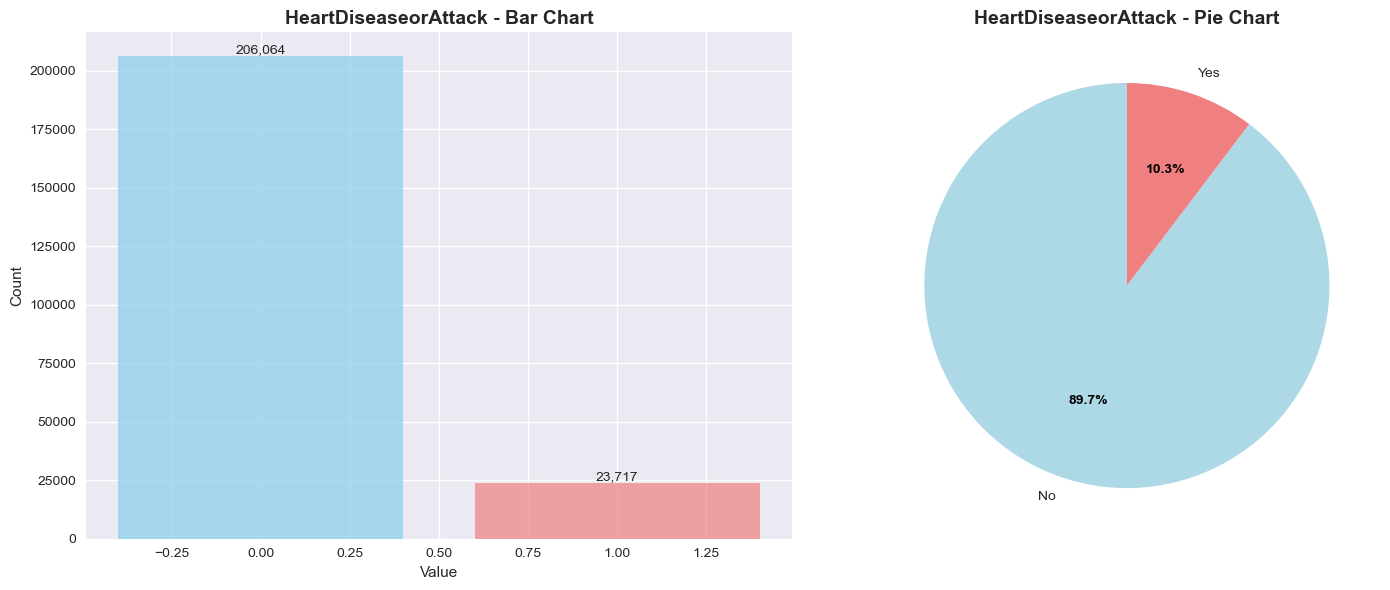


HeartDiseaseorAttack Summary:
Total count: 229781
Missing values: 0
Value counts:
HeartDiseaseorAttack
0    206064
1     23717
Name: count, dtype: int64
Percentage distribution:
HeartDiseaseorAttack
0    89.68
1    10.32
Name: count, dtype: float64
--------------------------------------------------


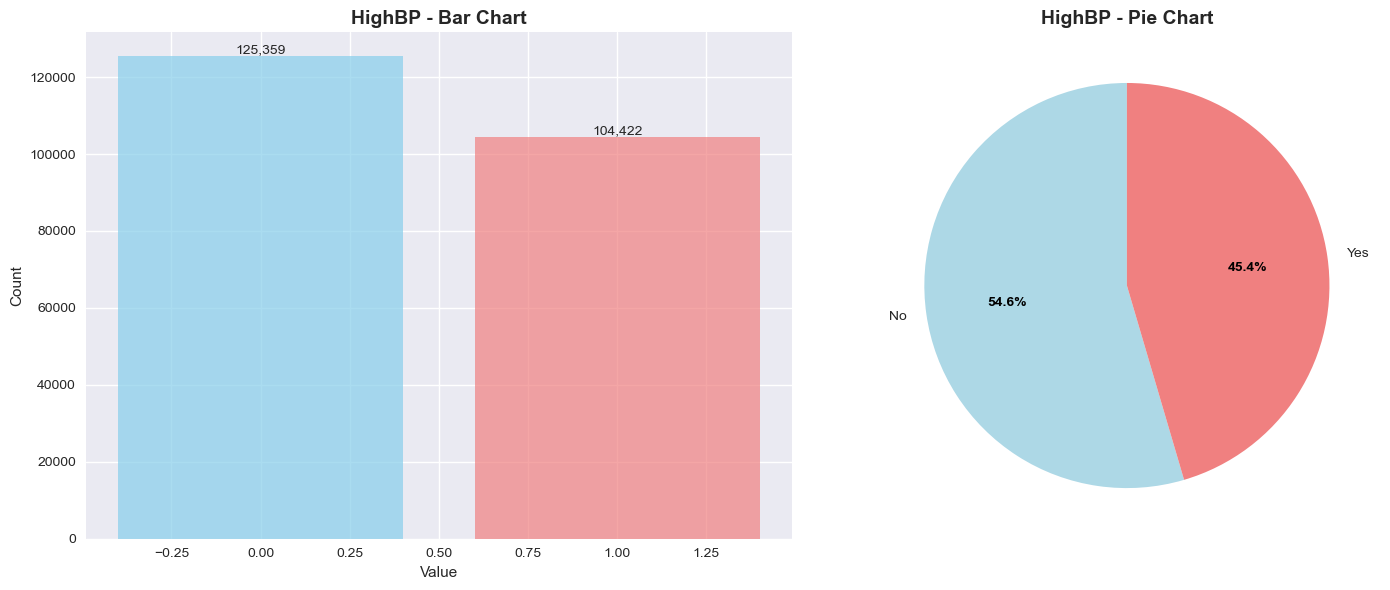


HighBP Summary:
Total count: 229781
Missing values: 0
Value counts:
HighBP
0    125359
1    104422
Name: count, dtype: int64
Percentage distribution:
HighBP
0    54.56
1    45.44
Name: count, dtype: float64
--------------------------------------------------


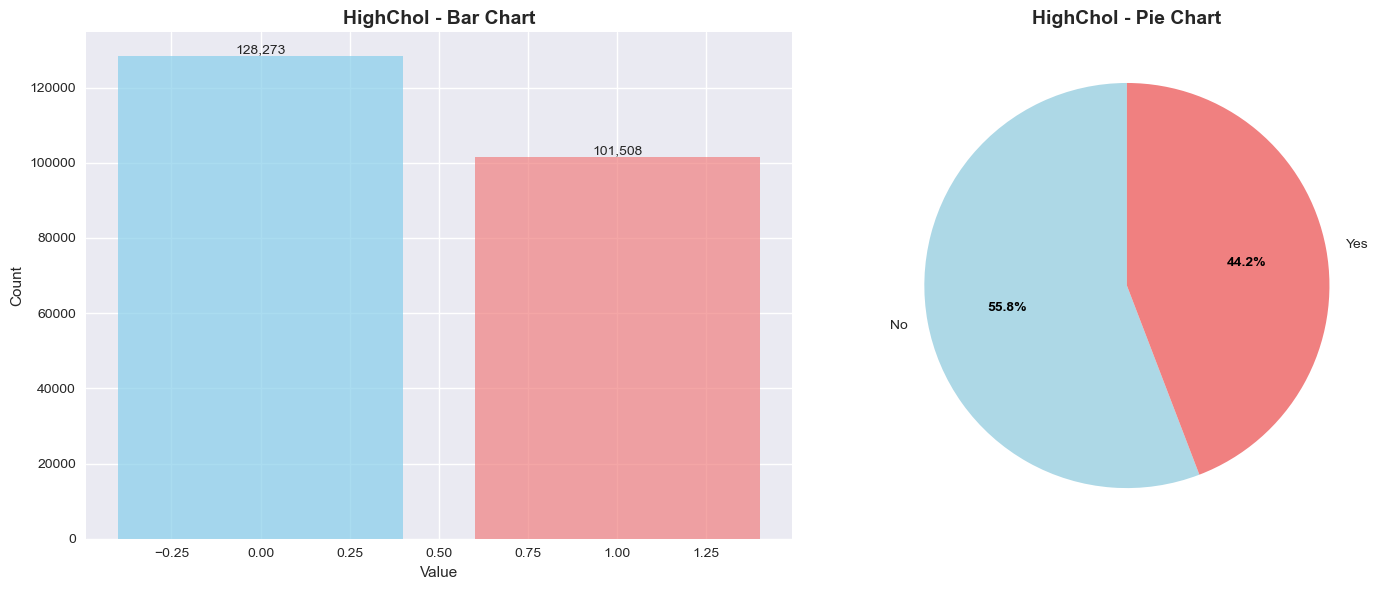


HighChol Summary:
Total count: 229781
Missing values: 0
Value counts:
HighChol
0    128273
1    101508
Name: count, dtype: int64
Percentage distribution:
HighChol
0    55.82
1    44.18
Name: count, dtype: float64
--------------------------------------------------


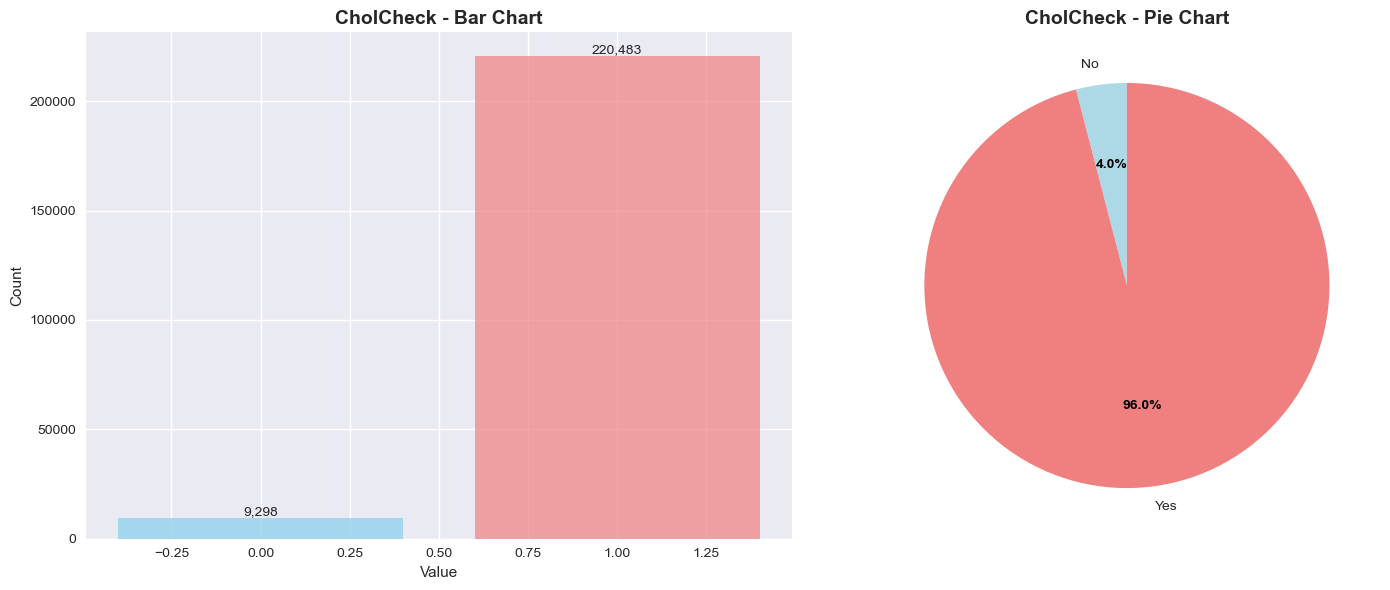


CholCheck Summary:
Total count: 229781
Missing values: 0
Value counts:
CholCheck
0      9298
1    220483
Name: count, dtype: int64
Percentage distribution:
CholCheck
0     4.05
1    95.95
Name: count, dtype: float64
--------------------------------------------------


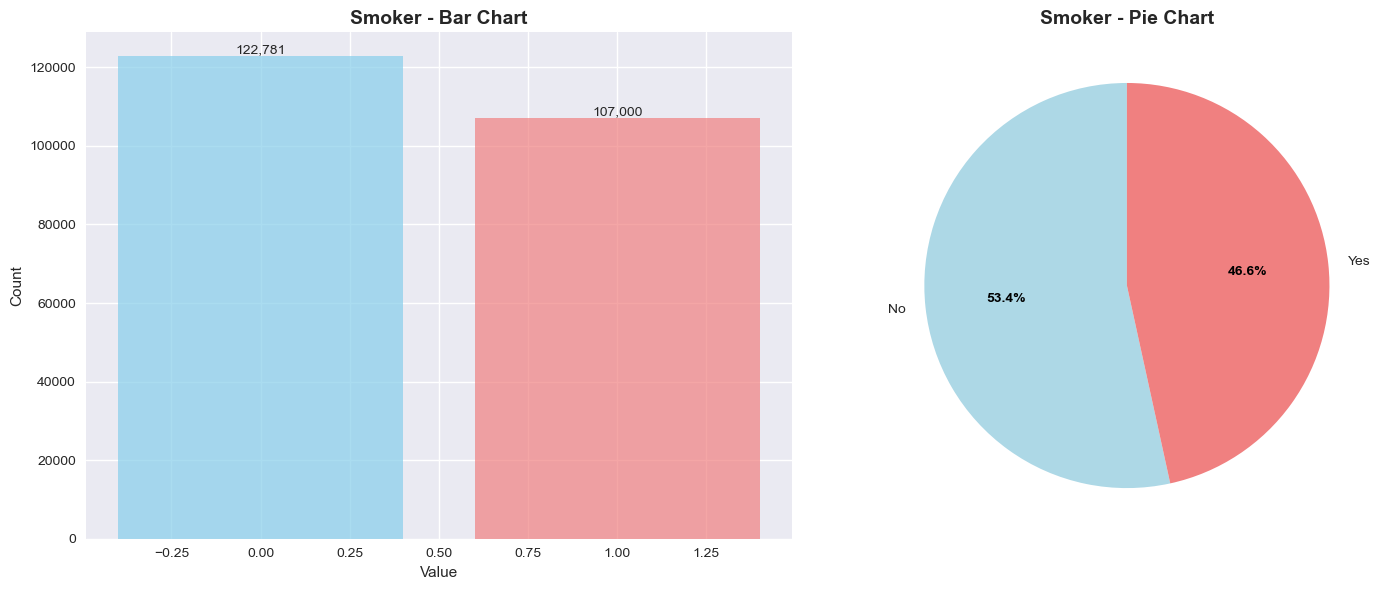


Smoker Summary:
Total count: 229781
Missing values: 0
Value counts:
Smoker
0    122781
1    107000
Name: count, dtype: int64
Percentage distribution:
Smoker
0    53.43
1    46.57
Name: count, dtype: float64
--------------------------------------------------


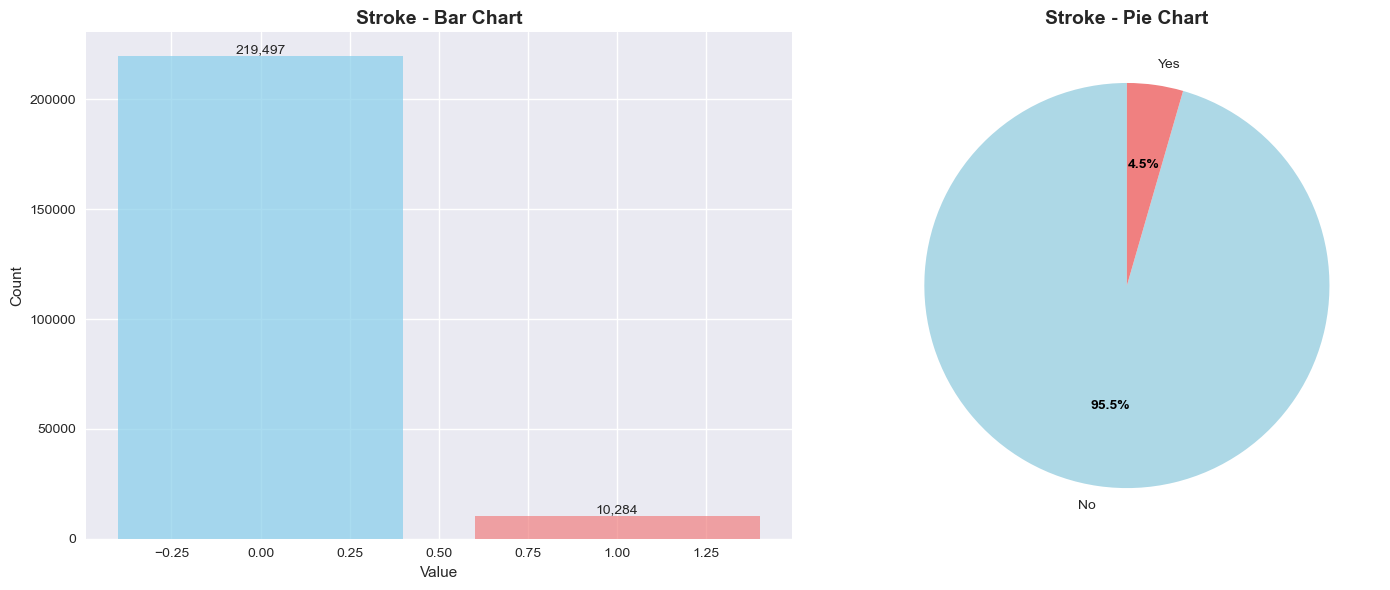


Stroke Summary:
Total count: 229781
Missing values: 0
Value counts:
Stroke
0    219497
1     10284
Name: count, dtype: int64
Percentage distribution:
Stroke
0    95.52
1     4.48
Name: count, dtype: float64
--------------------------------------------------


ValueError: 'label' must be of length 'x'

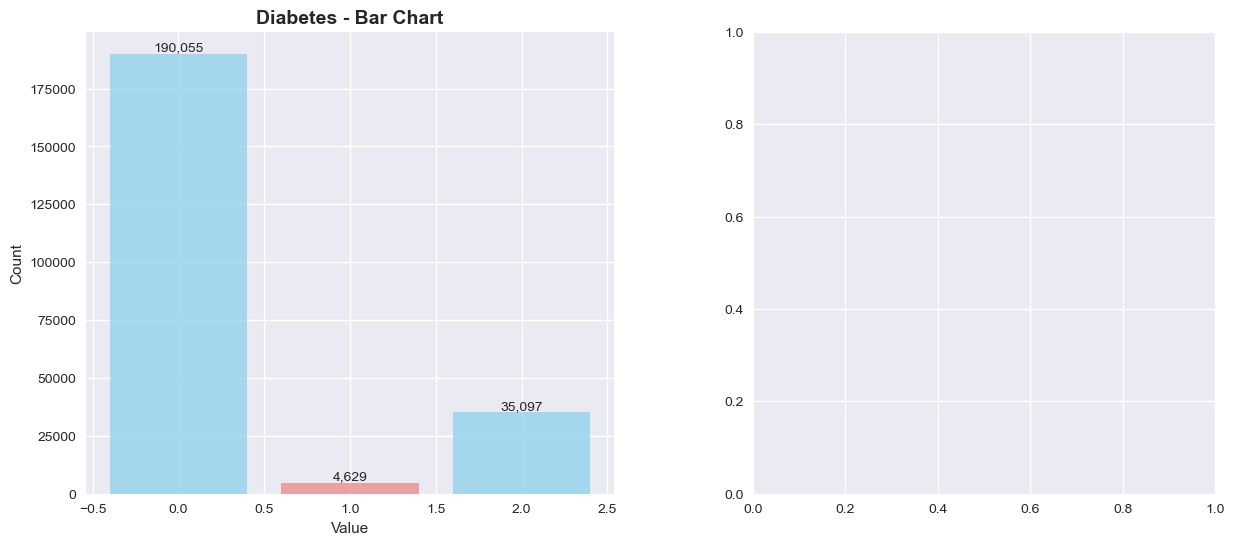

In [271]:
binary_cat = [
    'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
    'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

# Create individual plots for each variable
for col in binary_cat:
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart
    value_counts = df[col].value_counts().sort_index()
    bars = ax1.bar(value_counts.index, value_counts.values, color=['skyblue', 'lightcoral'], alpha=0.7)
    ax1.set_title(f'{col} - Bar Chart', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Count')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,}', ha='center', va='bottom')
    
    # Pie chart
    labels = ['No', 'Yes'] if col != 'Sex' else ['Female', 'Male']
    colors = ['lightblue', 'lightcoral']
    
    wedges, texts, autotexts = ax2.pie(value_counts.values, labels=labels, autopct='%1.1f%%',
                                      colors=colors, startangle=90)
    ax2.set_title(f'{col} - Pie Chart', fontsize=14, fontweight='bold')
    
    # Make autotexts bold
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{col} Summary:")
    print(f"Total count: {len(df[col])}")
    print(f"Missing values: {df[col].isna().sum()}")
    print(f"Value counts:\n{value_counts}")
    print(f"Percentage distribution:\n{(value_counts/len(df)*100).round(2)}")
    print("-" * 50)

In [112]:
df.shape

(229781, 22)

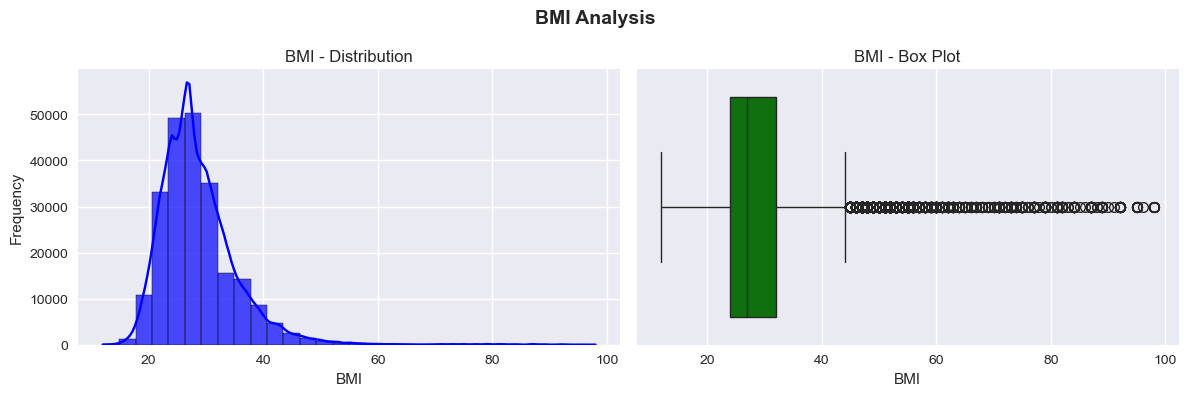

In [273]:
plt.figure(figsize=(12, 4))

# First subplot - Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['BMI'],kde=True,color='blue', alpha=0.7, bins=30)
plt.title('BMI - Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')

# Second subplot - Box plot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['BMI'], color='green')
plt.title('BMI - Box Plot')
plt.xlabel('BMI')

plt.suptitle('BMI Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

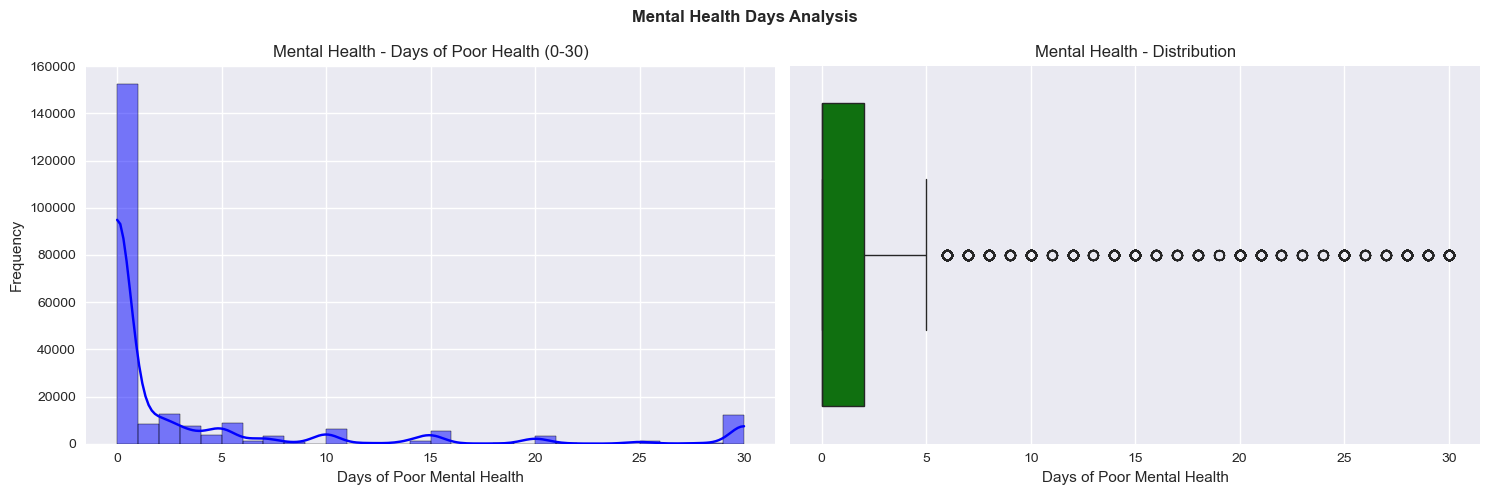

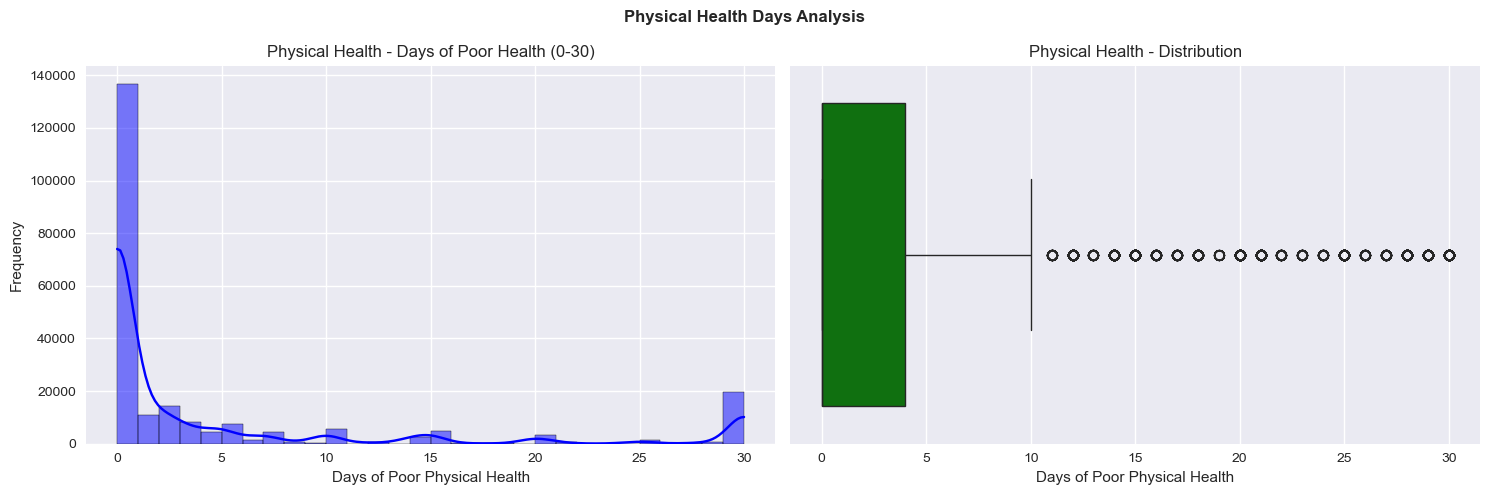

In [275]:
# Mental Health
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MentHlth'], bins=30, kde=True, color='blue')
plt.title('Mental Health - Days of Poor Health (0-30)')
plt.xlabel('Days of Poor Mental Health')
plt.ylabel('Frequency')
plt.xticks(range(0, 31, 5))

plt.subplot(1, 2, 2)
sns.boxplot(x=df['MentHlth'], color='green')
plt.title('Mental Health - Distribution')
plt.xlabel('Days of Poor Mental Health')

plt.suptitle('Mental Health Days Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

# Physical Health
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['PhysHlth'], bins=30, kde=True, color='blue')
plt.title('Physical Health - Days of Poor Health (0-30)')
plt.xlabel('Days of Poor Physical Health')
plt.ylabel('Frequency')
plt.xticks(range(0, 31, 5))

plt.subplot(1, 2, 2)
sns.boxplot(x=df['PhysHlth'], color='green')
plt.title('Physical Health - Distribution')
plt.xlabel('Days of Poor Physical Health')

plt.suptitle('Physical Health Days Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## for ordinal categories 
     ordinal_cat = ['GenHlth', 'Education', 'Income','Age']

C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\1442713356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=health_labels, y=health_counts.values, palette='viridis')


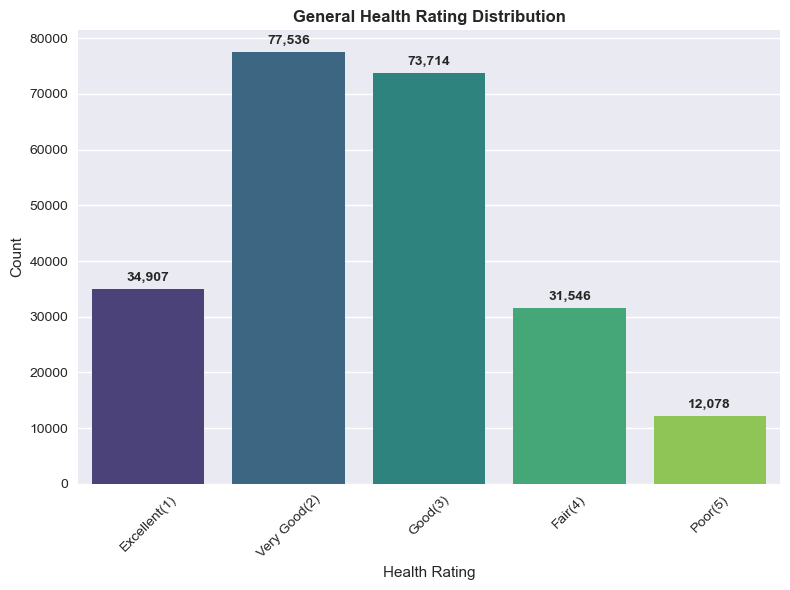

In [118]:
plt.figure(figsize=(8,6 ))
health_labels = ['Excellent(1)', 'Very Good(2)', 'Good(3)', 'Fair(4)', 'Poor(5)']
health_counts = df['GenHlth'].value_counts().sort_index()

sns.barplot(x=health_labels, y=health_counts.values, palette='viridis')
plt.title('General Health Rating Distribution', fontweight='bold')
plt.xlabel('Health Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels on bars
for i, count in enumerate(health_counts.values):
    plt.text(i, count + 1000, f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\2904649436.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='coolwarm')


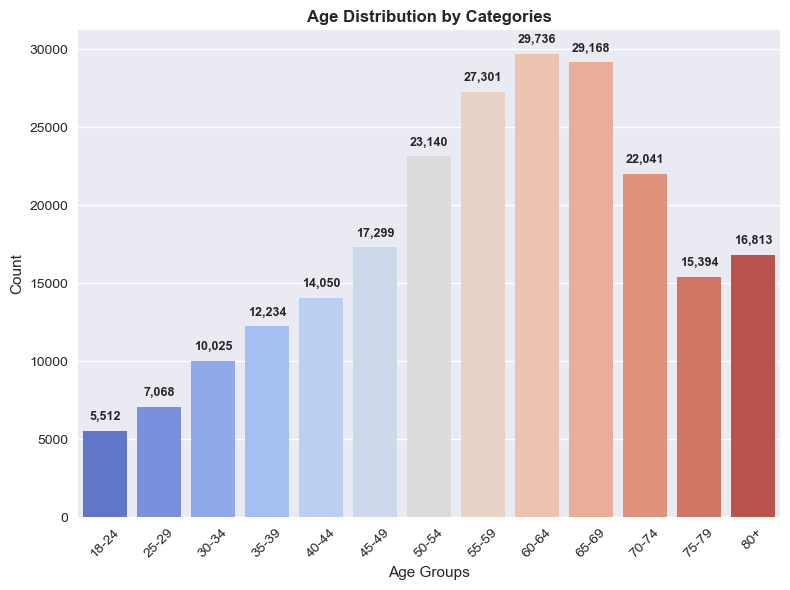

In [278]:
plt.figure(figsize=(8, 6))
age_categories = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
    6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
    11: '70-74', 12: '75-79', 13: '80+'
}

# Map age codes to labels
age_data = df['Age'].map(age_categories)
age_counts = age_data.value_counts().sort_index()

sns.barplot(x=age_counts.index, y=age_counts.values, palette='coolwarm')
plt.title('Age Distribution by Categories', fontweight='bold')
plt.xlabel('Age Groups')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Add value labels
for i, count in enumerate(age_counts.values):
    plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\2288128789.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=edu_counts.index, x=edu_counts.values, palette='Set2')


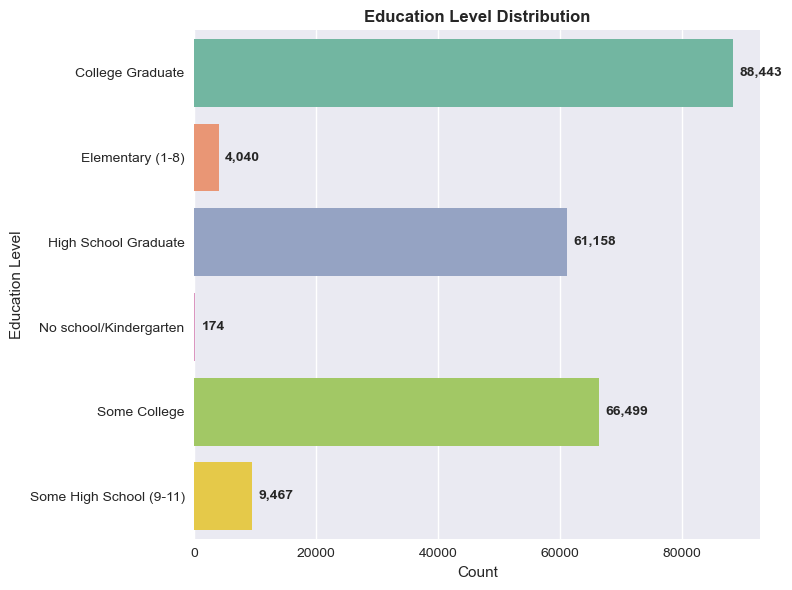

In [280]:
plt.figure(figsize=(8,6))
education_categories = {
    1: 'No school/Kindergarten',
    2: 'Elementary (1-8)',
    3: 'Some High School (9-11)',
    4: 'High School Graduate',
    5: 'Some College',
    6: 'College Graduate'
}

# Map education codes to labels
edu_data = df['Education'].map(education_categories)
edu_counts = edu_data.value_counts().sort_index()

sns.barplot(y=edu_counts.index, x=edu_counts.values, palette='Set2')
plt.title('Education Level Distribution', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Education Level')

# Add value labels
for i, count in enumerate(edu_counts.values):
    plt.text(count + 1000, i, f'{count:,}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\3990841403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=income_counts.index, x=income_counts.values, palette='RdYlGn')


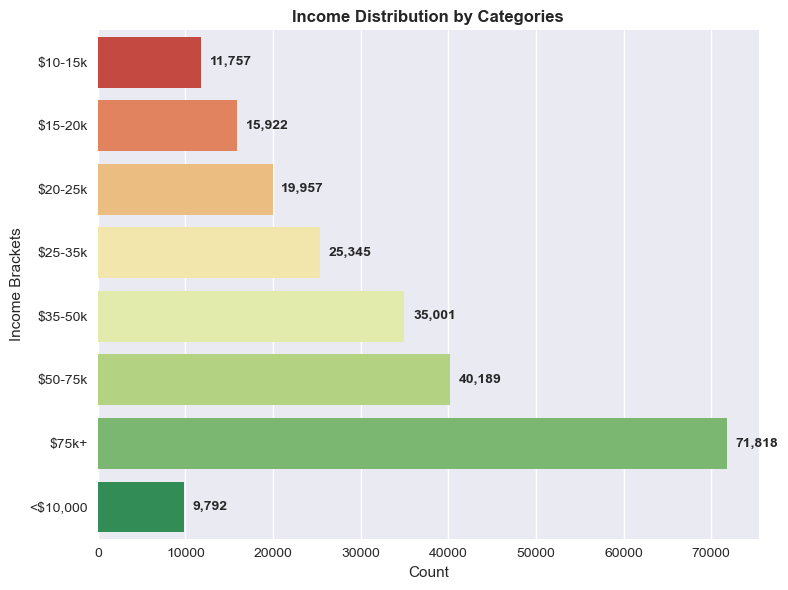

In [282]:
plt.figure(figsize=(8,6))
income_categories = {
    1: '<$10,000', 2: '$10-15k', 3: '$15-20k', 4: '$20-25k',
    5: '$25-35k', 6: '$35-50k', 7: '$50-75k', 8: '$75k+'
}

# Map income codes to labels
income_data = df['Income'].map(income_categories)
income_counts = income_data.value_counts().sort_index()

sns.barplot(y=income_counts.index, x=income_counts.values, palette='RdYlGn')
plt.title('Income Distribution by Categories', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Income Brackets')

# Add value labels
for i, count in enumerate(income_counts.values):
    plt.text(count + 1000, i, f'{count:,}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# EXPLORATORY DATA ANALAYSIS

## Data Overview & Preparation

In [284]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Basic dataset info
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nHeart Disease Prevalence: {df['HeartDiseaseorAttack'].mean():.2%}")

# Create mapped categorical variables
age_categories = {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
                  6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
                  11: '70-74', 12: '75-79', 13: '80+'}

education_categories = {
    1: 'Never attended/Kindergarten only',
    2: 'Elementary (Grades 1-8)', 
    3: 'Some high school (Grades 9-11)',
    4: 'High school graduate',
    5: 'Some college/Technical school',
    6: 'College graduate'
}

income_categories = {
    1: 'Less than $10,000', 2: '$10,000 to $14,999', 3: '$15,000 to $19,999',
    4: '$20,000 to $24,999', 5: '$25,000 to $34,999', 6: '$35,000 to $49,999',
    7: '$50,000 to $74,999', 8: '$75,000 or more'
}

gen_health_categories = {
    1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'
}

# Apply mappings
df['Age_Group'] = df['Age'].map(age_categories)
df['Education_Level'] = df['Education'].map(education_categories)
df['Income_Level'] = df['Income'].map(income_categories)
df['GenHlth_Category'] = df['GenHlth'].map(gen_health_categories)
df['Sex'] = df['Sex'].map({0: 'Female', 1: 'Male'})

# Create binary flags for better analysis
df['Any_Chronic_Disease'] = ((df['HighBP'] == 1) | (df['HighChol'] == 1) | (df['Diabetes'] == 1) | (df['Stroke'] == 1)).astype(int)
df['Unhealthy_Lifestyle'] = ((df['Smoker'] == 1) | (df['HvyAlcoholConsump'] == 1) | (df['PhysActivity'] == 0)).astype(int)
df['Total_Unhealthy_Days'] = df['MentHlth'] + df['PhysHlth']

Dataset Shape: (229781, 22)

Missing Values:
HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Heart Disease Prevalence: 10.32%


## Target Variable Analysis
 ### Heart disease by demographics analysiis

Axes shape: (2, 3)
Axes type: <class 'numpy.ndarray'>
Axes[0,0] exists: True
Axes[0,1] exists: True
Axes[0,2] exists: True
Axes[1,0] exists: True
Axes[1,1] exists: True
Axes[1,2] exists: True


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (2,)  and requested shape (3,)

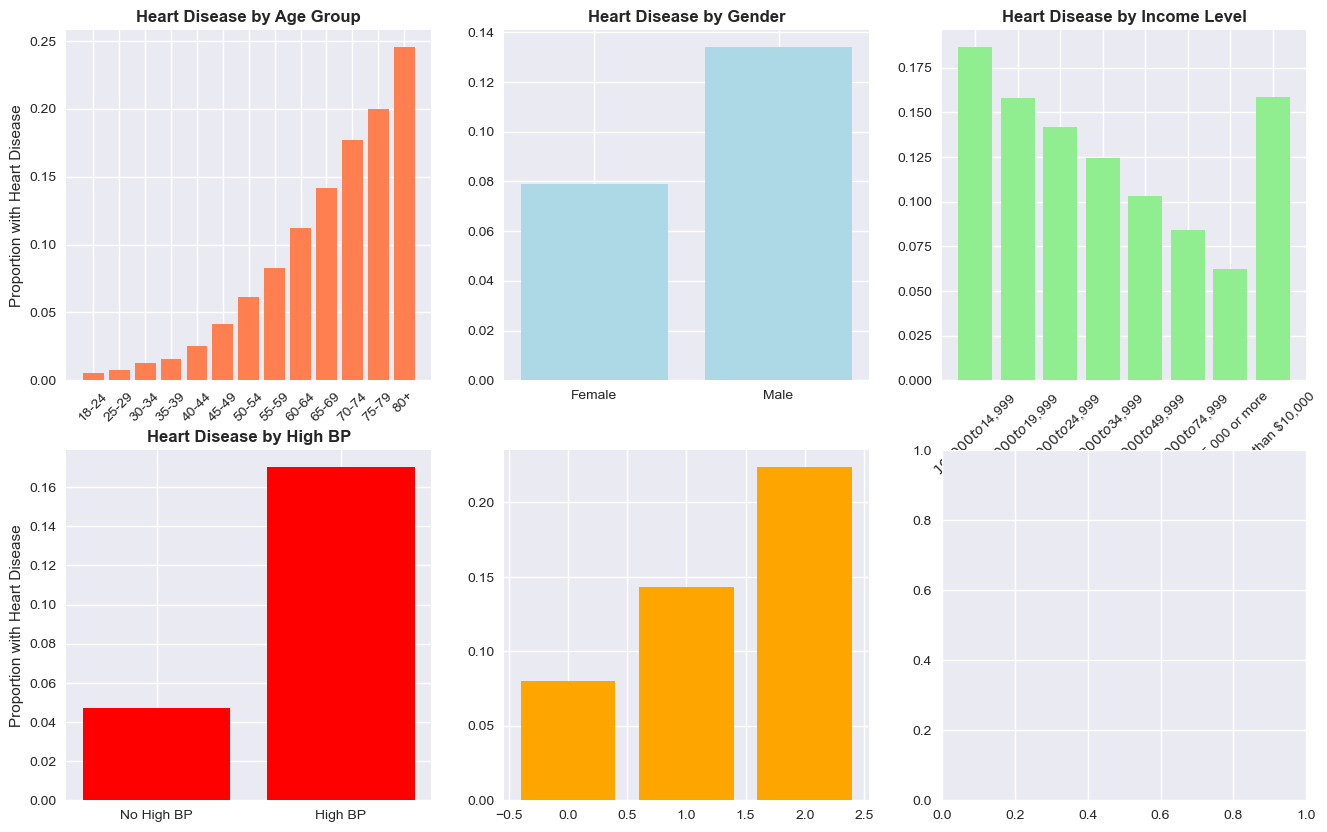

In [288]:
import matplotlib.pyplot as plt
import numpy as np

# Clear any existing figures
plt.close('all')

# Create fresh figure and verify axes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
print(f"Axes shape: {axes.shape}")  # Should print (2, 3)
print(f"Axes type: {type(axes)}")

# Verify each axis exists
for i in range(2):
    for j in range(3):
        print(f"Axes[{i},{j}] exists: {axes[i,j] is not None}")

# Now create the plots with explicit data handling
# Plot 1: Age Group
age_data = df.groupby('Age_Group')['HeartDiseaseorAttack'].mean()
if not age_data.empty:
    axes[0,0].bar(range(len(age_data)), age_data.values, color='coral', tick_label=age_data.index)
    axes[0,0].set_title('Heart Disease by Age Group', fontweight='bold')
    axes[0,0].set_ylabel('Proportion with Heart Disease')
    axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Gender
gender_data = df.groupby('Sex')['HeartDiseaseorAttack'].mean()
if not gender_data.empty:
    axes[0,1].bar(range(len(gender_data)), gender_data.values, color='lightblue', tick_label=['Female', 'Male'])
    axes[0,1].set_title('Heart Disease by Gender', fontweight='bold')

# Plot 3: Income Level
income_data = df.groupby('Income_Level')['HeartDiseaseorAttack'].mean()
if not income_data.empty:
    axes[0,2].bar(range(len(income_data)), income_data.values, color='lightgreen', tick_label=income_data.index)
    axes[0,2].set_title('Heart Disease by Income Level', fontweight='bold')
    axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: High BP
bp_data = df.groupby('HighBP')['HeartDiseaseorAttack'].mean()
if not bp_data.empty:
    axes[1,0].bar(range(len(bp_data)), bp_data.values, color='red', tick_label=['No High BP', 'High BP'])
    axes[1,0].set_title('Heart Disease by High BP', fontweight='bold')
    axes[1,0].set_ylabel('Proportion with Heart Disease')

# Plot 5: Diabetes
diabetes_data = df.groupby('Diabetes')['HeartDiseaseorAttack'].mean()
if not diabetes_data.empty:
    axes[1,1].bar(range(len(diabetes_data)), diabetes_data.values, color='orange', tick_label=['No Diabetes', 'Diabetes'])
    axes[1,1].set_title('Heart Disease by Diabetes', fontweight='bold')

# Plot 6: General Health
health_data = df.groupby('GenHlth_Category')['HeartDiseaseorAttack'].mean()
if not health_data.empty:
    axes[1,2].bar(range(len(health_data)), health_data.values, color='purple', tick_label=health_data.index)
    axes[1,2].set_title('Heart Disease by General Health', fontweight='bold')
    axes[1,2].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for i in range(2):
    for j in range(3):
        if not axes[i,j].has_data():
            axes[i,j].set_visible(False)

plt.tight_layout()
plt.show()

## Risk Factors Correlation Analysis

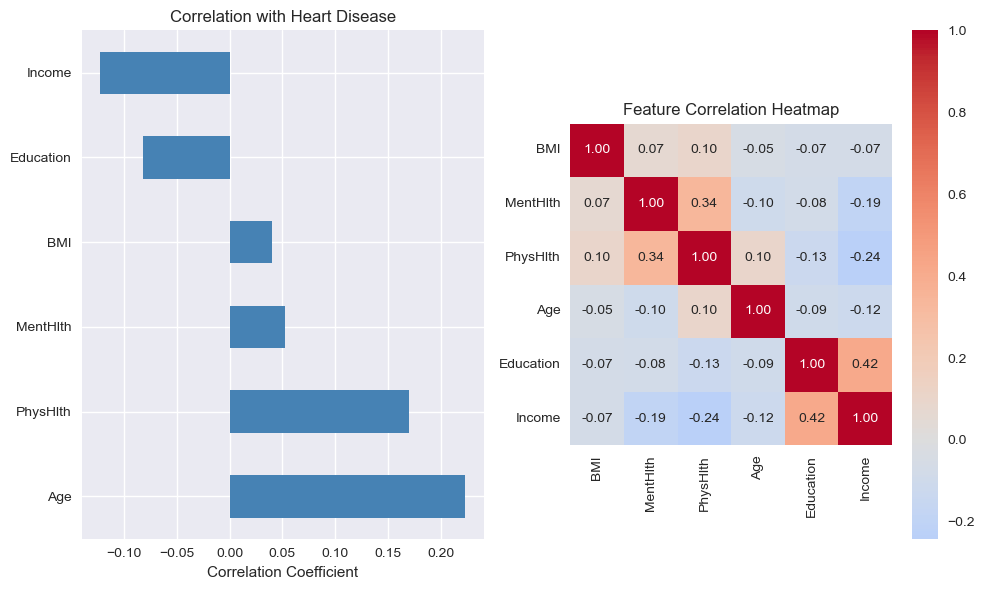

In [290]:
# Correlation matrix for numerical variables
numerical_vars = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
plt.figure(figsize=(10, 6))

# Calculate correlations with target
correlation_with_target = df[numerical_vars + ['HeartDiseaseorAttack']].corr()['HeartDiseaseorAttack'].sort_values(ascending=False)

plt.subplot(1, 2, 1)
correlation_with_target.drop('HeartDiseaseorAttack').plot(kind='barh', color='steelblue')
plt.title('Correlation with Heart Disease')
plt.xlabel('Correlation Coefficient')

# Heatmap of feature correlations
plt.subplot(1, 2, 2)
corr_matrix = df[numerical_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## Lifestyle Factors Analysis

Lifestyle factors impact on heart disease


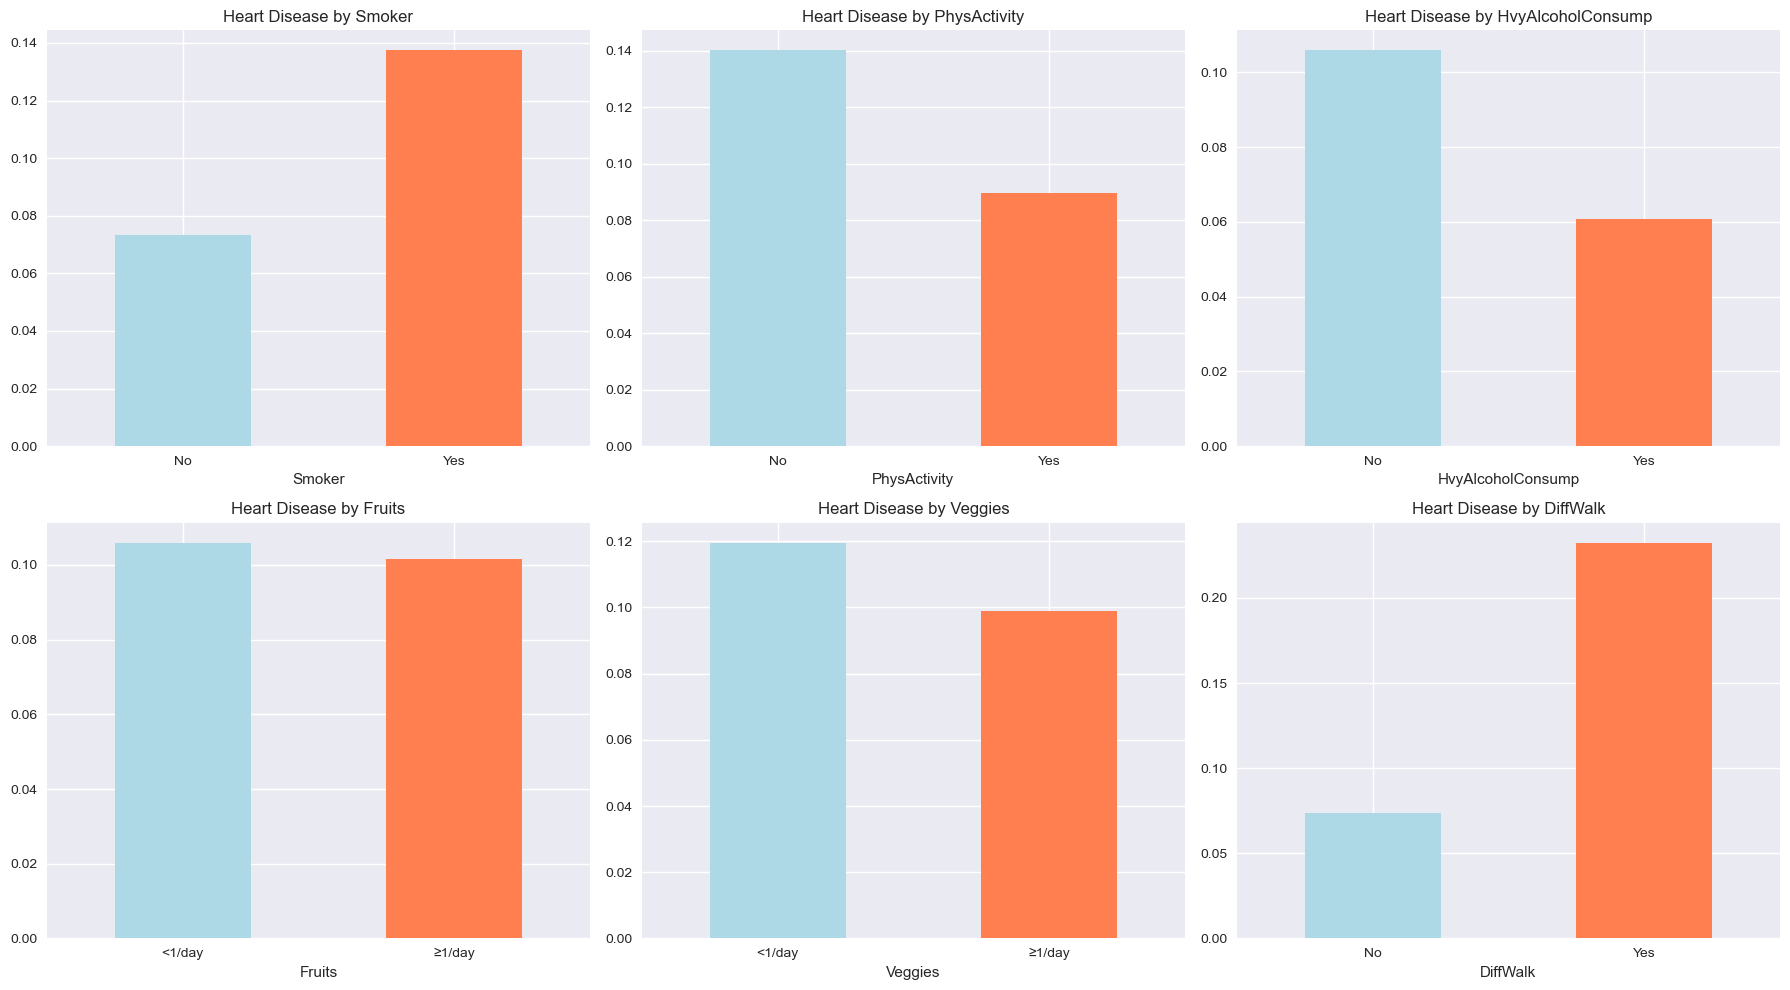

In [197]:
print("Lifestyle factors impact on heart disease")
lifestyle_factors = ['Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'Fruits', 'Veggies', 'DiffWalk']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, factor in enumerate(lifestyle_factors):
    row, col = i // 3, i % 3
    df.groupby(factor)['HeartDiseaseorAttack'].mean().plot(kind='bar', ax=axes[row, col], color=['lightblue', 'coral'])
    axes[row, col].set_title(f'Heart Disease by {factor}')
    if factor in ['Smoker', 'PhysActivity', 'HvyAlcoholConsump', 'DiffWalk']:
        axes[row, col].set_xticklabels(['No', 'Yes'], rotation=0)
    elif factor in ['Fruits', 'Veggies']:
        axes[row, col].set_xticklabels(['<1/day', '≥1/day'], rotation=0)

plt.tight_layout()
plt.show()

##  Feature Engineering for ML

In [292]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Feature engineering
df_ml = df.copy()

# Create interaction terms
df_ml['Age_HighBP'] = df_ml['Age'] * df_ml['HighBP']
df_ml['BMI_Diabetes'] = df_ml['BMI'] * df_ml['Diabetes']
df_ml['HighBP_Diabetes'] = df_ml['HighBP'] * df_ml['Diabetes']
df_ml['Total_Unhealthy_Days'] = df_ml['MentHlth'] + df_ml['PhysHlth']
df_ml['Any_Chronic_Disease'] = ((df_ml['HighBP'] == 1) | (df_ml['HighChol'] == 1) | 
                               (df_ml['Diabetes'] == 1) | (df_ml['Stroke'] == 1)).astype(int)

# Select features for modeling - use only numerical columns initially
feature_columns = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 
    'Education', 'Income', 'Age_HighBP', 'BMI_Diabetes', 'HighBP_Diabetes',
    'Total_Unhealthy_Days', 'Any_Chronic_Disease'
]

# Check for non-numeric columns and handle them
print("Data types in feature columns:")
for col in feature_columns:
    print(f"{col}: {df_ml[col].dtype}")

X = df_ml[feature_columns]
y = df_ml['HeartDiseaseorAttack']

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Heart disease prevalence in training: {y_train.mean():.3f}")
print(f"Heart disease prevalence in test: {y_test.mean():.3f}")

Data types in feature columns:
HighBP: int32
HighChol: int32
CholCheck: int32
BMI: int32
Smoker: int32
Stroke: int32
Diabetes: int32
PhysActivity: int32
Fruits: int32
Veggies: int32
HvyAlcoholConsump: int32
AnyHealthcare: int32
NoDocbcCost: int32
GenHlth: int32
MentHlth: int32
PhysHlth: int32
DiffWalk: int32
Age: int32
Education: int32
Income: int32
Age_HighBP: int32
BMI_Diabetes: int32
HighBP_Diabetes: int32
Total_Unhealthy_Days: int32
Any_Chronic_Disease: int32

Features shape: (229781, 25)
Target distribution:
HeartDiseaseorAttack
0    0.896784
1    0.103216
Name: proportion, dtype: float64

Training set: 183824 samples
Test set: 45957 samples
Heart disease prevalence in training: 0.103
Heart disease prevalence in test: 0.103


## Model Training & Evaluation


Training Logistic Regression...
CV AUC: 0.8258 (+/- 0.0035)
Test AUC: 0.8259
Test Accuracy: 0.7223

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.72      0.82     41214
   Heart Disease       0.24      0.78      0.37      4743

        accuracy                           0.72     45957
       macro avg       0.60      0.75      0.59     45957
    weighted avg       0.89      0.72      0.78     45957



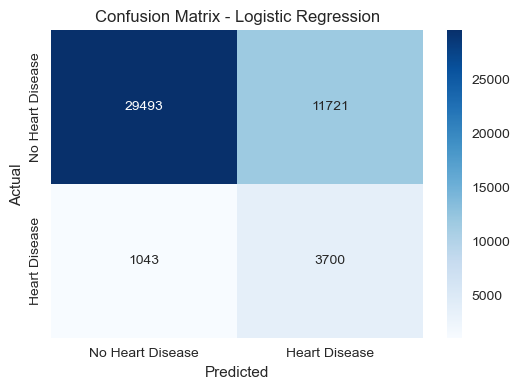


Training Random Forest...
CV AUC: 0.7831 (+/- 0.0025)
Test AUC: 0.7813
Test Accuracy: 0.8880

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.98      0.94     41214
   Heart Disease       0.33      0.08      0.14      4743

        accuracy                           0.89     45957
       macro avg       0.62      0.53      0.54     45957
    weighted avg       0.84      0.89      0.86     45957



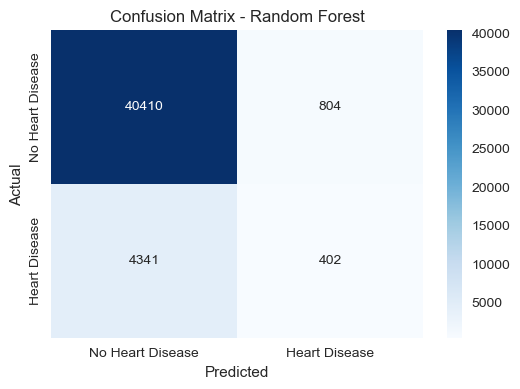


Training Gradient Boosting...
CV AUC: 0.8279 (+/- 0.0024)
Test AUC: 0.8281
Test Accuracy: 0.8985

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.99      0.95     41214
   Heart Disease       0.55      0.09      0.15      4743

        accuracy                           0.90     45957
       macro avg       0.73      0.54      0.55     45957
    weighted avg       0.87      0.90      0.86     45957



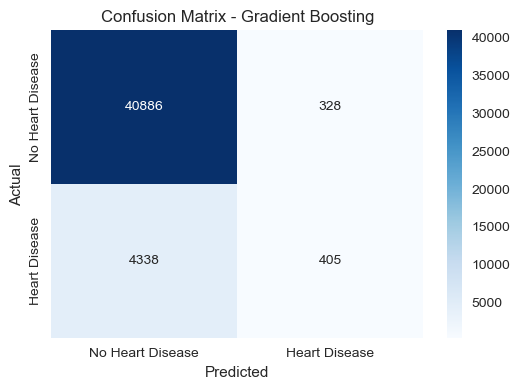

In [294]:
# Initialize models - we'll use models that don't require scaling
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print('='*50)
    
    # For Logistic Regression, we need to handle scaling separately
    if name == 'Logistic Regression':
        # Scale only numerical features for Logistic Regression
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        # Tree-based models don't need scaling
        X_tr, X_te = X_train, X_test
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='roc_auc')
    
    # Train model
    model.fit(X_tr, y_train)
    
    # Predictions
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_te)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)
    else:
        y_pred = model.predict(X_te)
        y_pred_proba = None
    
    # Calculate metrics
    accuracy = (y_pred == y_test).mean()
    auc_score = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Store results
    results[name] = {
        'model': model,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'test_auc': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    if auc_score is not None:
        print(f"Test AUC: {auc_score:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Heart Disease', 'Heart Disease'],
                yticklabels=['No Heart Disease', 'Heart Disease'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## Model Comparison & ROC Curves


Model Performance Comparison:
                 Model  CV_AUC_Mean  CV_AUC_Std  Test_AUC  Test_Accuracy
0  Logistic Regression       0.8258      0.0017    0.8259         0.7223
1        Random Forest       0.7831      0.0012    0.7813         0.8880
2    Gradient Boosting       0.8279      0.0012    0.8281         0.8985


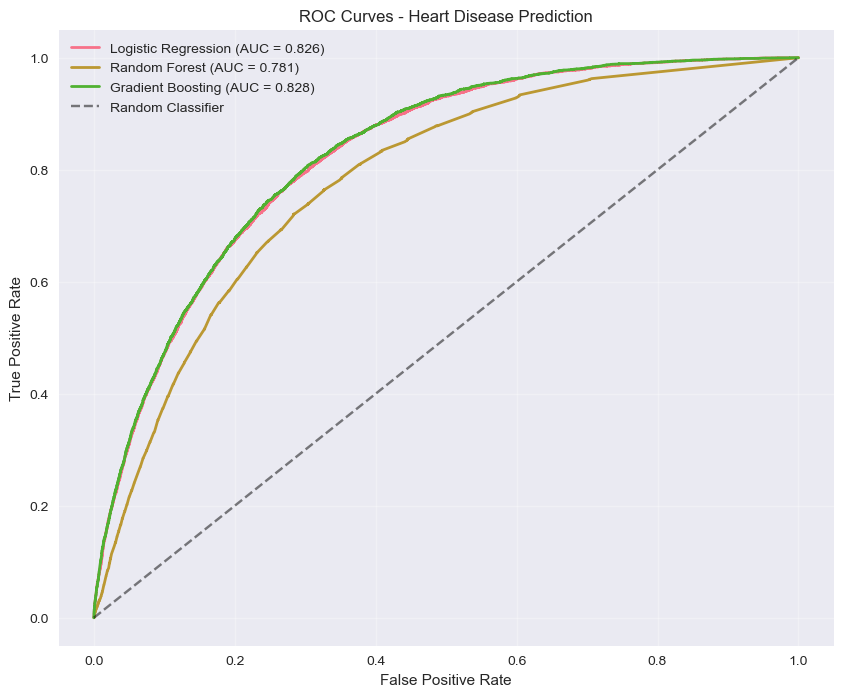

In [296]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_AUC_Mean': [results[name]['cv_auc_mean'] for name in results.keys()],
    'CV_AUC_Std': [results[name]['cv_auc_std'] for name in results.keys()],
    'Test_AUC': [results[name]['test_auc'] for name in results.keys()],
    'Test_Accuracy': [results[name]['test_accuracy'] for name in results.keys()]
})

print("\nModel Performance Comparison:")
print(comparison_df.round(4))

# ROC Curves
plt.figure(figsize=(10, 8))
for name, result in results.items():
    if result['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
        auc_score = result['test_auc']
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Heart Disease Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Feature Importance Analysis

C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\2347444733.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')


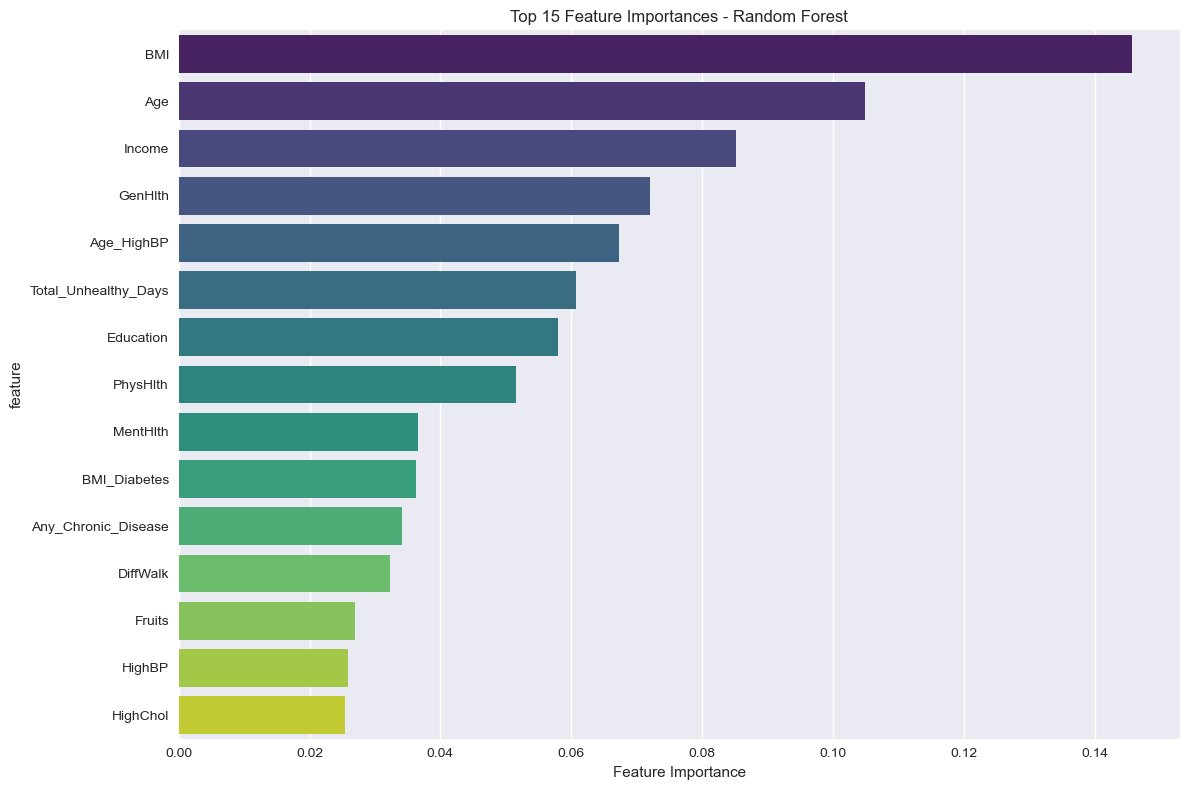

Top 10 Most Important Features for Heart Disease Prediction:
                 feature  importance
3                    BMI      0.1458
17                   Age      0.1049
19                Income      0.0852
13               GenHlth      0.0720
20            Age_HighBP      0.0673
23  Total_Unhealthy_Days      0.0608
18             Education      0.0580
15              PhysHlth      0.0515
14              MentHlth      0.0366
21          BMI_Diabetes      0.0362


In [298]:
# Feature Importance from Random Forest (most interpretable)
rf_model = results['Random Forest']['model']

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features for Heart Disease Prediction:")
print(feature_importance.head(10).round(4))

## Risk Factor Analysis with Demographic Insights


Demographic Analysis (Separate from Model):


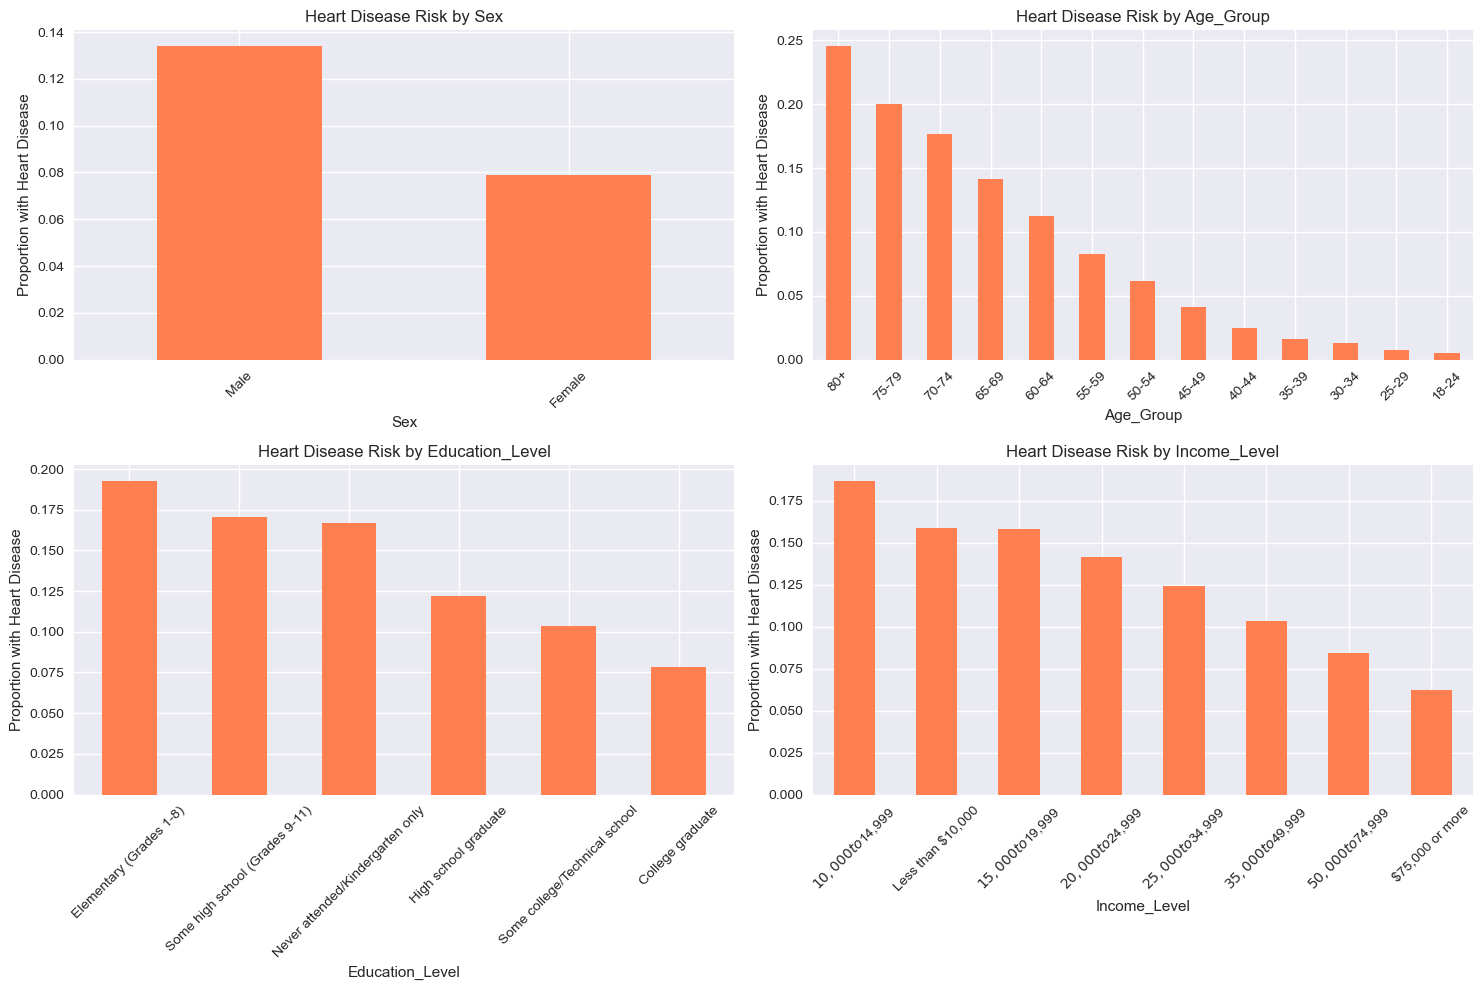


Detailed Analysis of Top 5 Risk Factors:

BMI:
  Risk by quartiles:
    Q1: 0.081
    Q2: 0.100
    Q3: 0.113
    Q4: 0.121

Age:
  Risk by quartiles:
    Q1: 0.022
    Q2: 0.073
    Q3: 0.127
    Q4: 0.205

Income:


C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\748811810.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_quartile = df_ml.groupby(f'{feature}_quartile')['HeartDiseaseorAttack'].mean()
C:\Users\pooja\AppData\Local\Temp\ipykernel_22604\748811810.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_quartile = df_ml.groupby(f'{feature}_quartile')['HeartDiseaseorAttack'].mean()


ValueError: Bin edges must be unique: Index([1.0, 5.0, 6.0, 8.0, 8.0], dtype='float64', name='Income').
You can drop duplicate edges by setting the 'duplicates' kwarg

In [300]:
# Add demographic analysis separately since we excluded Sex from main model
print("\nDemographic Analysis (Separate from Model):")
demographic_factors = ['Sex', 'Age_Group', 'Education_Level', 'Income_Level']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, factor in enumerate(demographic_factors):
    row, col = i // 2, i % 2
    risk_by_group = df_ml.groupby(factor)['HeartDiseaseorAttack'].mean().sort_values(ascending=False)
    risk_by_group.plot(kind='bar', ax=axes[row, col], color='coral')
    axes[row, col].set_title(f'Heart Disease Risk by {factor}')
    axes[row, col].set_ylabel('Proportion with Heart Disease')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Detailed risk analysis for top features
top_5_features = feature_importance.head(5)['feature'].tolist()

print("\nDetailed Analysis of Top 5 Risk Factors:")
for feature in top_5_features:
    print(f"\n{feature}:")
    if df_ml[feature].nunique() <= 5:  # Binary or categorical
        risk_by_level = df_ml.groupby(feature)['HeartDiseaseorAttack'].mean().sort_values(ascending=False)
        for level, risk in risk_by_level.items():
            count = (df_ml[feature] == level).sum()
            print(f"  Level {level}: {risk:.3f} (n={count})")
    else:  # Continuous
        # Show quartile analysis
        df_ml[f'{feature}_quartile'] = pd.qcut(df_ml[feature], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        risk_by_quartile = df_ml.groupby(f'{feature}_quartile')['HeartDiseaseorAttack'].mean()
        print(f"  Risk by quartiles:")
        for quartile, risk in risk_by_quartile.items():
            print(f"    {quartile}: {risk:.3f}")

# IDENTIFY SIZE OF DATASET  IWH IMBALANCE

In [302]:
total_samples = 229781
minority_class = int(229781 * 0.103)  # ≈ 23,667
minority_percentage = 10.3

print(f"📊 Total samples: {total_samples:,}")
print(f"❤️  Heart disease cases: {minority_class:,}")
print(f"📈 Minority percentage: {minority_percentage}%")
print(f"⚖️  Imbalance ratio: {90:10} or 8.7:1")

# Classification
if total_samples > 100000 and minority_class > 5000:
    print("\n🔍 VERDICT: LARGE DATASET with SUBSTANTIAL MINORITY CLASS")
    print("📍 CATEGORY: LARGE DATASET")

📊 Total samples: 229,781
❤️  Heart disease cases: 23,667
📈 Minority percentage: 10.3%
⚖️  Imbalance ratio:         90 or 8.7:1

🔍 VERDICT: LARGE DATASET with SUBSTANTIAL MINORITY CLASS
📍 CATEGORY: LARGE DATASET


In [148]:
def imbalance_handling_recommendation(total_samples, minority_samples):
    """
    Recommend resampling strategy based on dataset characteristics
    """
    minority_ratio = minority_samples / total_samples
    
    print(f"Dataset Analysis:")
    print(f"  Total samples: {total_samples:,}")
    print(f"  Minority samples: {minority_samples:,}")
    print(f"  Minority ratio: {minority_ratio:.3f}")
    print(f"  Imbalance ratio: {total_samples/minority_samples:.1f}:1")
    
    # Decision matrix
    if total_samples < 10000:
        if minority_samples < 500:
            return "SMOTE + Ensemble (Small dataset, few minority samples)"
        else:
            return "SMOTE (Small dataset, reasonable minority)"
    
    elif total_samples < 100000:
        if minority_samples < 1000:
            return "SMOTEENN (Medium dataset, moderate imbalance)"
        else:
            return "SMOTE + Class Weights (Medium dataset)"
    
    else:  # Large datasets
        if minority_samples < 5000:
            return "Class Weights Only (Large dataset, highly imbalanced)"
        else:
            return "Class Weights (Large dataset, substantial minority)"

# Test with different scenarios
scenarios = [
    (5000, 100),    # Small, highly imbalanced
    (50000, 5000),  # Medium, manageable
    (229781, 23667) # Your case: Large, substantial minority
]

for total, minority in scenarios:
    recommendation = imbalance_handling_recommendation(total, minority)
    print(f"\nScenario: {total:,} total, {minority:,} minority")
    print(f"Recommendation: {recommendation}")

Dataset Analysis:
  Total samples: 5,000
  Minority samples: 100
  Minority ratio: 0.020
  Imbalance ratio: 50.0:1

Scenario: 5,000 total, 100 minority
Recommendation: SMOTE + Ensemble (Small dataset, few minority samples)
Dataset Analysis:
  Total samples: 50,000
  Minority samples: 5,000
  Minority ratio: 0.100
  Imbalance ratio: 10.0:1

Scenario: 50,000 total, 5,000 minority
Recommendation: SMOTE + Class Weights (Medium dataset)
Dataset Analysis:
  Total samples: 229,781
  Minority samples: 23,667
  Minority ratio: 0.103
  Imbalance ratio: 9.7:1

Scenario: 229,781 total, 23,667 minority
Recommendation: Class Weights (Large dataset, substantial minority)


In [304]:
def print_size_reference_table():
    """
    Print quick reference table for dataset size classification
    """
    print("📊 DATASET SIZE CLASSIFICATION REFERENCE")
    print("=" * 50)
    print(f"{'CATEGORY':<15} {'SAMPLES':<20} {'TYPICAL USE'}")
    print("-" * 50)
    
    categories = [
        ("VERY SMALL", "< 1,000", "Prototyping, Education"),
        ("SMALL", "1,000 - 10,000", "Small Projects, Research"),
        ("MEDIUM", "10,000 - 100,000", "Commercial Applications"),
        ("LARGE", "100,000 - 1M", "Enterprise Systems"),
        ("VERY LARGE", "> 1,000,000", "Big Data, Tech Giants")
    ]
    
    for category, samples, use in categories:
        print(f"{category:<15} {samples:<20} {use}")

print_size_reference_table()

📊 DATASET SIZE CLASSIFICATION REFERENCE
CATEGORY        SAMPLES              TYPICAL USE
--------------------------------------------------
VERY SMALL      < 1,000              Prototyping, Education
SMALL           1,000 - 10,000       Small Projects, Research
MEDIUM          10,000 - 100,000     Commercial Applications
LARGE           100,000 - 1M         Enterprise Systems
VERY LARGE      > 1,000,000          Big Data, Tech Giants


In [306]:
def industry_standard_classification(total_samples, data_type="tabular"):
    """
    Industry standard dataset size classification
    
    Parameters:
    total_samples (int): Total number of samples in the dataset
    data_type (str): Type of data - "tabular", "image", or "text"
    
    Returns:
    tuple: (category, description) - Size category and description
    """
    if data_type == "tabular":
        criteria = {
            "VERY SMALL": "< 1,000 samples",
            "SMALL": "1,000 - 10,000 samples", 
            "MEDIUM": "10,000 - 100,000 samples",
            "LARGE": "100,000 - 1,000,000 samples",
            "VERY LARGE": "> 1,000,000 samples"
        }
    elif data_type == "image":
        criteria = {
            "VERY SMALL": "< 1,000 images",
            "SMALL": "1,000 - 10,000 images",
            "MEDIUM": "10,000 - 100,000 images", 
            "LARGE": "100,000 - 1,000,000 images",
            "VERY LARGE": "> 1,000,000 images"
        }
    elif data_type == "text":
        criteria = {
            "VERY SMALL": "< 10,000 documents",
            "SMALL": "10,000 - 100,000 documents",
            "MEDIUM": "100,000 - 1,000,000 documents",
            "LARGE": "1,000,000 - 10,000,000 documents", 
            "VERY LARGE": "> 10,000,000 documents"
        }
    else:
        raise ValueError("data_type must be 'tabular', 'image', or 'text'")
    
    # Find category based on total_samples
    if total_samples < 1000:
        category = "VERY SMALL"
    elif total_samples < 10000:
        category = "SMALL"
    elif total_samples < 100000:
        category = "MEDIUM"
    elif total_samples < 1000000:
        category = "LARGE"
    else:
        category = "VERY LARGE"
    
    return category, criteria[category]

In [ ]:
# Test with different dataset sizes
test_sizes = [500, 5000, 50000, 500000, 5000000]

print("Dataset Size Classification Examples:")
print("=" * 50)

for size in test_sizes:
    category, description = industry_standard_classification(size, "tabular")
    print(f"{size:>8,} samples → {category:<12} ({description})")

In [160]:
def industry_standard_classification(total_samples, minority_samples=None, data_type="tabular"):
    """
    Industry standard dataset size classification with imbalance handling recommendations
    
    Parameters:
    total_samples (int): Total number of samples in the dataset
    minority_samples (int): Number of samples in minority class (for imbalanced data)
    data_type (str): Type of data - "tabular", "image", or "text"
    
    Returns:
    dict: Comprehensive classification with algorithm recommendations
    """
    # Define size criteria
    if data_type == "tabular":
        criteria = {
            "VERY SMALL": "< 1,000 samples",
            "SMALL": "1,000 - 10,000 samples", 
            "MEDIUM": "10,000 - 100,000 samples",
            "LARGE": "100,000 - 1,000,000 samples",
            "VERY LARGE": "> 1,000,000 samples"
        }
    elif data_type == "image":
        criteria = {
            "VERY SMALL": "< 1,000 images",
            "SMALL": "1,000 - 10,000 images",
            "MEDIUM": "10,000 - 100,000 images", 
            "LARGE": "100,000 - 1,000,000 images",
            "VERY LARGE": "> 1,000,000 images"
        }
    elif data_type == "text":
        criteria = {
            "VERY SMALL": "< 10,000 documents",
            "SMALL": "10,000 - 100,000 documents",
            "MEDIUM": "100,000 - 1,000,000 documents",
            "LARGE": "1,000,000 - 10,000,000 documents", 
            "VERY LARGE": "> 10,000,000 documents"
        }
    
    # Determine size category
    if total_samples < 1000:
        size_category = "VERY SMALL"
    elif total_samples < 10000:
        size_category = "SMALL"
    elif total_samples < 100000:
        size_category = "MEDIUM"
    elif total_samples < 1000000:
        size_category = "LARGE"
    else:
        size_category = "VERY LARGE"
    
    # Imbalance analysis
    imbalance_info = {}
    if minority_samples is not None:
        imbalance_ratio = (total_samples - minority_samples) / minority_samples
        minority_percentage = (minority_samples / total_samples) * 100
        
        # Classify imbalance severity
        if minority_percentage < 1:
            imbalance_level = "EXTREME IMBALANCE"
        elif minority_percentage < 5:
            imbalance_level = "SEVERE IMBALANCE"
        elif minority_percentage < 10:
            imbalance_level = "MODERATE IMBALANCE"
        elif minority_percentage < 20:
            imbalance_level = "MILD IMBALANCE"
        else:
            imbalance_level = "RELATIVELY BALANCED"
        
        imbalance_info = {
            'imbalance_level': imbalance_level,
            'minority_percentage': minority_percentage,
            'imbalance_ratio': imbalance_ratio,
            'minority_samples': minority_samples
        }
    
    # Algorithm recommendations based on size and imbalance
    recommendations = get_algorithm_recommendations(size_category, imbalance_info, data_type)
    
    return {
        'size_category': size_category,
        'size_description': criteria[size_category],
        'data_type': data_type,
        'total_samples': total_samples,
        'imbalance_info': imbalance_info,
        'recommendations': recommendations
    }


def get_algorithm_recommendations(size_category, imbalance_info, data_type):
    """
    Get suitable algorithms based on dataset size and imbalance
    """
    recommendations = {
        'resampling_strategy': [],
        'algorithms': [],
        'special_techniques': [],
        'warning': None
    }
    
    has_imbalance = imbalance_info and imbalance_info.get('imbalance_level') != "RELATIVELY BALANCED"
    imbalance_level = imbalance_info.get('imbalance_level', 'BALANCED') if imbalance_info else 'BALANCED'
    
    # Recommendations based on dataset size and imbalance
    if size_category == "VERY SMALL":
        recommendations['warning'] = "Very limited data - consider collecting more samples"
        
        if has_imbalance:
            recommendations['resampling_strategy'] = ["SMOTE", "ADASYN", "BorderlineSMOTE"]
            recommendations['algorithms'] = ["Logistic Regression (with class_weight)", "SVM (with class_weight)", "XGBoost (scale_pos_weight)"]
            recommendations['special_techniques'] = ["Stratified K-Fold", "Leave-One-Out Cross Validation"]
        else:
            recommendations['algorithms'] = ["Logistic Regression", "K-Nearest Neighbors", "Decision Trees", "Naive Bayes"]
            recommendations['special_techniques'] = ["Stratified K-Fold", "Feature Selection"]
    
    elif size_category == "SMALL":
        if has_imbalance:
            if imbalance_level in ["EXTREME IMBALANCE", "SEVERE IMBALANCE"]:
                recommendations['resampling_strategy'] = ["SMOTE", "SMOTEENN", "RandomOverSampler"]
                recommendations['algorithms'] = ["Random Forest (class_weight)", "XGBoost (scale_pos_weight)", "LightGBM (is_unbalance=True)"]
            else:
                recommendations['resampling_strategy'] = ["SMOTE", "ADASYN"]
                recommendations['algorithms'] = ["Random Forest", "XGBoost", "SVM"]
            recommendations['special_techniques'] = ["Stratified Cross Validation", "Ensemble Methods"]
        else:
            recommendations['algorithms'] = ["Random Forest", "XGBoost", "SVM", "Logistic Regression"]
            recommendations['special_techniques'] = ["Cross Validation", "Hyperparameter Tuning"]
    
    elif size_category == "MEDIUM":
        if has_imbalance:
            recommendations['resampling_strategy'] = ["SMOTE", "SMOTEENN", "Class Weights (preferred)"]
            recommendations['algorithms'] = [
                "Random Forest (class_weight='balanced')", 
                "XGBoost (scale_pos_weight)", 
                "LightGBM (is_unbalance=True)",
                "CatBoost (auto_class_weights)"
            ]
            recommendations['special_techniques'] = ["Class Weights", "Threshold Moving", "Cost-Sensitive Learning"]
        else:
            recommendations['algorithms'] = ["Random Forest", "XGBoost", "LightGBM", "Neural Networks"]
            recommendations['special_techniques'] = ["Hyperparameter Optimization", "Feature Engineering"]
    
    elif size_category == "LARGE":
        if has_imbalance:
            # For large datasets, prefer class weights over resampling
            recommendations['resampling_strategy'] = ["Class Weights (RECOMMENDED)", "RandomUnderSampler", "SMOTE (if computational resources allow)"]
            recommendations['algorithms'] = [
                "XGBoost (scale_pos_weight)", 
                "LightGBM (is_unbalance=True)", 
                "Random Forest (class_weight='balanced')",
                "Neural Networks (class_weight)"
            ]
            recommendations['special_techniques'] = ["Class Weights", "Ensemble Methods", "Distributed Computing"]
        else:
            recommendations['algorithms'] = ["XGBoost", "LightGBM", "Neural Networks", "Random Forest"]
            recommendations['special_techniques'] = ["Distributed Training", "Feature Importance Analysis"]
    
    elif size_category == "VERY LARGE":
        recommendations['warning'] = "Consider distributed computing frameworks"
        if has_imbalance:
            recommendations['resampling_strategy'] = ["Class Weights (BEST)", "Undersampling (if necessary)"]
            recommendations['algorithms'] = [
                "XGBoost (scale_pos_weight)", 
                "LightGBM (is_unbalance=True)", 
                "Neural Networks (class_weight)",
                "Spark MLlib algorithms"
            ]
            recommendations['special_techniques'] = ["Distributed Computing", "Mini-batch Learning", "Online Learning"]
        else:
            recommendations['algorithms'] = ["XGBoost", "LightGBM", "Neural Networks", "Spark MLlib"]
            recommendations['special_techniques'] = ["Distributed Systems", "Online Learning", "Feature Streaming"]
    
    # Data-type specific adjustments
    if data_type == "image" and has_imbalance:
        recommendations['resampling_strategy'].extend(["Data Augmentation", "Oversampling with Augmentation"])
        recommendations['algorithms'].extend(["CNN with Focal Loss", "Transfer Learning with class weights"])
    
    elif data_type == "text" and has_imbalance:
        recommendations['resampling_strategy'].extend(["Text Data Augmentation", "SMOTE for embeddings"])
        recommendations['algorithms'].extend(["BERT with class weights", "LSTM with Focal Loss"])
    
    return recommendations


def print_classification_result(result):
    """
    Pretty print the classification results
    """
    print(f"\n📊 DATASET CLASSIFICATION RESULTS")
    print("=" * 60)
    print(f"Size Category: {result['size_category']}")
    print(f"Description: {result['size_description']}")
    print(f"Data Type: {result['data_type']}")
    print(f"Total Samples: {result['total_samples']:,}")
    
    if result['imbalance_info']:
        print(f"\n⚖️  IMBALANCE ANALYSIS:")
        print(f"  Level: {result['imbalance_info']['imbalance_level']}")
        print(f"  Minority %: {result['imbalance_info']['minority_percentage']:.2f}%")
        print(f"  Imbalance Ratio: {result['imbalance_info']['imbalance_ratio']:.1f}:1")
        print(f"  Minority Samples: {result['imbalance_info']['minority_samples']:,}")
    
    print(f"\n🎯 RECOMMENDATIONS:")
    print(f"  Resampling Strategies: {', '.join(result['recommendations']['resampling_strategy'])}")
    print(f"  Algorithms: {', '.join(result['recommendations']['algorithms'])}")
    print(f"  Techniques: {', '.join(result['recommendations']['special_techniques'])}")
    
    if result['recommendations']['warning']:
        print(f"  ⚠️  Warning: {result['recommendations']['warning']}")
    
    print("=" * 60)


# Now run the examples
if __name__ == "__main__":
    # Example 1: Small imbalanced dataset
    print("Example 1: Small Imbalanced Dataset")
    result1 = industry_standard_classification(
        total_samples=5000, 
        minority_samples=250,  # 5% minority
        data_type="tabular"
    )
    print_classification_result(result1)

    # Example 2: Large balanced dataset  
    print("\nExample 2: Large Balanced Dataset")
    result2 = industry_standard_classification(
        total_samples=200000,
        data_type="tabular"
    )
    print_classification_result(result2)

    # Example 3: Medium imbalanced image dataset
    print("\nExample 3: Medium Imbalanced Image Dataset")
    result3 = industry_standard_classification(
        total_samples=50000,
        minority_samples=2500,  # 5% minority
        data_type="image"
    )
    print_classification_result(result3)

    # Example 4: Very large extremely imbalanced text dataset
    print("\nExample 4: Very Large Extremely Imbalanced Text Dataset")
    result4 = industry_standard_classification(
        total_samples=2000000,
        minority_samples=10000,  # 0.5% minority - extreme imbalance
        data_type="text"
    )
    print_classification_result(result4)

Example 1: Small Imbalanced Dataset

📊 DATASET CLASSIFICATION RESULTS
Size Category: SMALL
Description: 1,000 - 10,000 samples
Data Type: tabular
Total Samples: 5,000

⚖️  IMBALANCE ANALYSIS:
  Level: MODERATE IMBALANCE
  Minority %: 5.00%
  Imbalance Ratio: 19.0:1
  Minority Samples: 250

🎯 RECOMMENDATIONS:
  Resampling Strategies: SMOTE, ADASYN
  Algorithms: Random Forest, XGBoost, SVM
  Techniques: Stratified Cross Validation, Ensemble Methods

Example 2: Large Balanced Dataset

📊 DATASET CLASSIFICATION RESULTS
Size Category: LARGE
Description: 100,000 - 1,000,000 samples
Data Type: tabular
Total Samples: 200,000

🎯 RECOMMENDATIONS:
  Resampling Strategies: 
  Algorithms: XGBoost, LightGBM, Neural Networks, Random Forest
  Techniques: Distributed Training, Feature Importance Analysis

Example 3: Medium Imbalanced Image Dataset

📊 DATASET CLASSIFICATION RESULTS
Size Category: MEDIUM
Description: 10,000 - 100,000 images
Data Type: image
Total Samples: 50,000

⚖️  IMBALANCE ANALYSIS:
 

## cOMPARISON OF APPROACHES: for this data set
    Method	           Resulting Dataset Size	Training Time	Risk	  Recommendation
    Class Weights    	229,781	                 Fast ✅	    Low ✅	  BEST CHOICE
    SMOTE	           ~450,000	                 Slow ❌	    Medium	  Not recommended
    SMOTEENN	      Variable	                 Slow ❌	    High ❌	    Avoid

## FINAL ALGORITHM AFTER SEEING DATASET SIZE AND  WITH HANDLIG IMBALANCED 

##  FROM BASE MODEL TO EXCELLENT

####  TSPLIT THE DATA AND IMPORT ALL LIBRARIES 

In [308]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare your data
X = df.drop('HeartDiseaseorAttack', axis=1)
y = df['HeartDiseaseorAttack']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale_pos_weight: {scale_pos_weight:.2f}")

Scale_pos_weight: 8.69


### BASE MODEL RANDOM FOREST

In [310]:
rf_model = RandomForestClassifier(
    class_weight='balanced',  # Handles imbalance
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

ValueError: could not convert string to float: 'Female'

## FINAL MODEL 

In [312]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Identify categorical columns
def identify_column_types(df):
    categorical_cols = []
    numerical_cols = []
    
    for col in df.columns:
        if df[col].dtype == 'object':
            categorical_cols.append(col)
        else:
            numerical_cols.append(col)
    
    return categorical_cols, numerical_cols

categorical_cols, numerical_cols = identify_column_types(df)
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Encode categorical variables
def encode_categorical_features(df, categorical_cols):
    df_encoded = df.copy()
    label_encoders = {}
    
    for col in categorical_cols:
        if col != 'HeartDiseaseorAttack':  # Don't encode target
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            label_encoders[col] = le
            print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    
    return df_encoded, label_encoders

# Apply encoding
df_encoded, label_encoders = encode_categorical_features(df, categorical_cols)

# Prepare features and target
X = df_encoded.drop('HeartDiseaseorAttack', axis=1)
y = df_encoded['HeartDiseaseorAttack']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Heart disease cases in training: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Heart disease cases in test: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Categorical columns: ['Sex', 'Age_Group', 'Education_Level', 'Income_Level', 'GenHlth_Category']
Numerical columns: ['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'Any_Chronic_Disease', 'Unhealthy_Lifestyle', 'Total_Unhealthy_Days']
Encoded Sex: {'Female': 0, 'Male': 1}
Encoded Age_Group: {'18-24': 0, '25-29': 1, '30-34': 2, '35-39': 3, '40-44': 4, '45-49': 5, '50-54': 6, '55-59': 7, '60-64': 8, '65-69': 9, '70-74': 10, '75-79': 11, '80+': 12}
Encoded Education_Level: {'College graduate': 0, 'Elementary (Grades 1-8)': 1, 'High school graduate': 2, 'Never attended/Kindergarten only': 3, 'Some college/Technical school': 4, 'Some high school (Grades 9-11)': 5}
Encoded Income_Level: {'$10,000 to $14,999': 0, '$15,000 to $19,999': 1, '$20,000 to $24,999': 2, '$25,000 to $34,9

In [173]:
# Calculate scale_pos_weight for handling imbalance
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Scale_pos_weight: {scale_pos_weight:.2f}")

# 1. XGBoost (RECOMMENDED) - Handles categorical encoding well
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric=['logloss', 'auc', 'error'],
    early_stopping_rounds=50
)

# Train XGBoost
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. LightGBM (Excellent for categorical features)
lgb_model = LGBMClassifier(
    is_unbalance=True,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 3. Random Forest (Handle categorical encoding)
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. LOGISTIC REGRESSION with Class Weights (NEW ADDITION)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features for Logistic Regression (important for convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with balanced class weights
lr_model = LogisticRegression(
    class_weight='balanced',  # Handles the 8.7:1 imbalance
    random_state=42,
    max_iter=1000,
    C=1.0,  # Regularization strength
    solver='liblinear',  # Good for smaller datasets
    penalty='l2'  # L2 regularization
)

lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Logistic Regression trained with class weights")

Scale_pos_weight: 8.69
✅ Logistic Regression trained with class weights


In [314]:
def comprehensive_evaluation(y_true, y_pred, y_pred_proba, model_name):
    """Evaluate model with all metrics"""
    
    try:
        # Calculate metrics
        auc_roc = roc_auc_score(y_true, y_pred_proba)
        avg_precision = average_precision_score(y_true, y_pred_proba)
        
        # Classification report
        report = classification_report(y_true, y_pred, output_dict=True)
        precision_1 = report['1']['precision']
        recall_1 = report['1']['recall']
        f1_1 = report['1']['f1-score']
        accuracy = report['accuracy']
        
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)  # True Negative Rate
        
        print(f"\n📊 {model_name} PERFORMANCE:")
        print("=" * 50)
        print(f"ROC-AUC: {auc_roc:.4f}")
        print(f"Average Precision: {avg_precision:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision (Heart Disease): {precision_1:.4f}")
        print(f"Recall/Sensitivity (Heart Disease): {recall_1:.4f}")
        print(f"F1-Score (Heart Disease): {f1_1:.4f}")
        print(f"Specificity: {specificity:.4f}")
        
        return {
            'model': model_name,
            'roc_auc': auc_roc,
            'avg_precision': avg_precision,
            'precision': precision_1,
            'recall': recall_1,
            'f1': f1_1,
            'specificity': specificity,
            'confusion_matrix': cm
        }
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")
        return None

# Evaluate all models including Logistic Regression
results = []
results.append(comprehensive_evaluation(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBoost"))
results.append(comprehensive_evaluation(y_test, y_pred_lgb, y_pred_proba_lgb, "LightGBM"))
results.append(comprehensive_evaluation(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest"))
results.append(comprehensive_evaluation(y_test, y_pred_lr, y_pred_proba_lr, "Logistic Regression"))

# Remove None results
results = [r for r in results if r is not None]


📊 XGBoost PERFORMANCE:
ROC-AUC: 0.8237
Average Precision: 0.3481
Accuracy: 0.7656
Precision (Heart Disease): 0.2653
Recall/Sensitivity (Heart Disease): 0.7183
F1-Score (Heart Disease): 0.3874
Specificity: 0.7710

📊 LightGBM PERFORMANCE:
ROC-AUC: 0.8363
Average Precision: 0.3723
Accuracy: 0.7319
Precision (Heart Disease): 0.2489
Recall/Sensitivity (Heart Disease): 0.7919
F1-Score (Heart Disease): 0.3788
Specificity: 0.7250

📊 Random Forest PERFORMANCE:
ROC-AUC: 0.8333
Average Precision: 0.3645
Accuracy: 0.7321
Precision (Heart Disease): 0.2482
Recall/Sensitivity (Heart Disease): 0.7862
F1-Score (Heart Disease): 0.3773
Specificity: 0.7259

📊 Logistic Regression PERFORMANCE:
ROC-AUC: 0.8356
Average Precision: 0.3723
Accuracy: 0.7400
Precision (Heart Disease): 0.2531
Recall/Sensitivity (Heart Disease): 0.7784
F1-Score (Heart Disease): 0.3820
Specificity: 0.7356


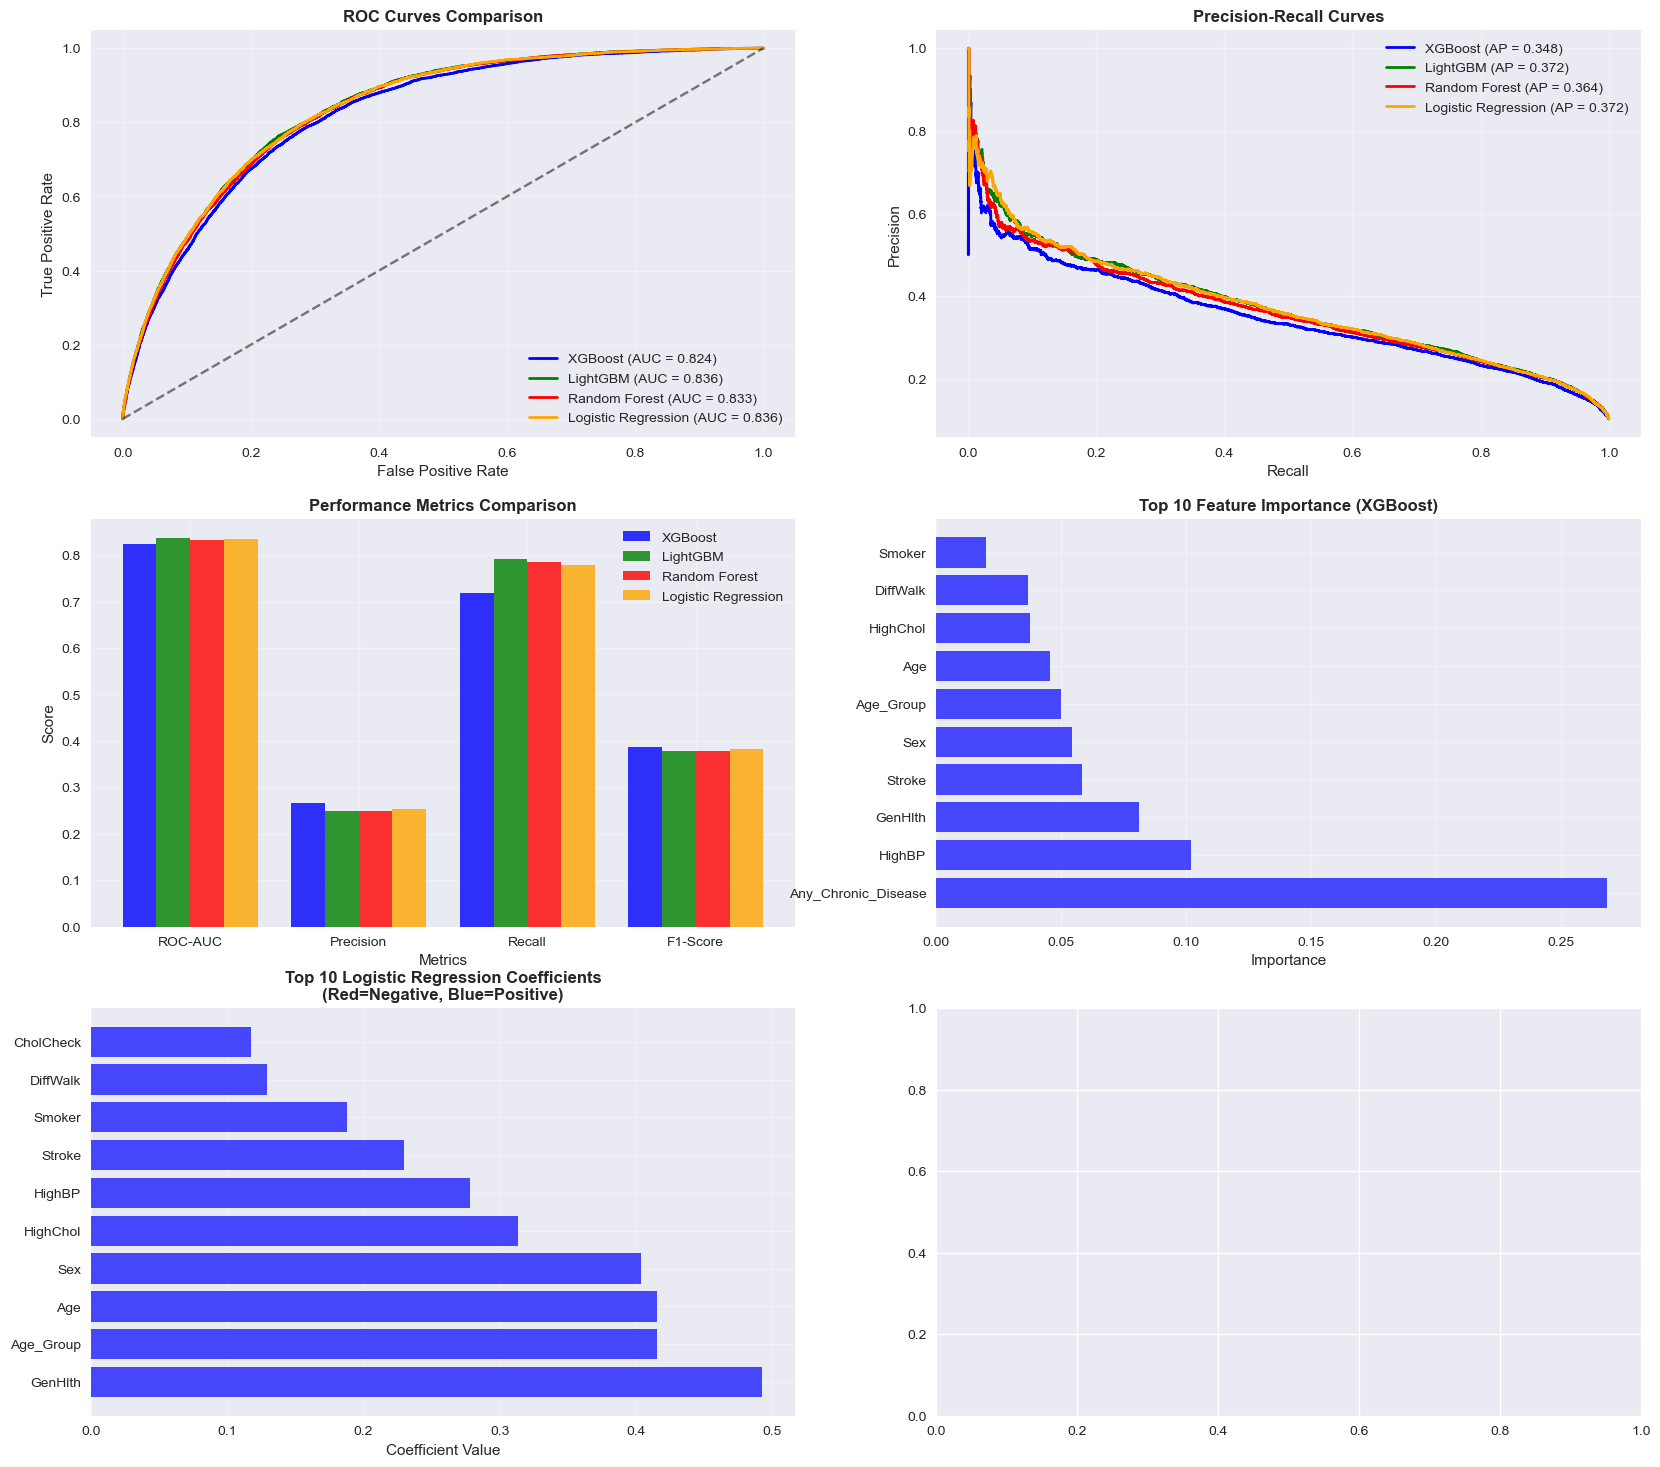

In [372]:
def plot_comprehensive_comparison(results, y_test, models_proba, model_names):
    """Create comprehensive visualization including Logistic Regression"""
    
    # Create 3x2 subplot layout
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    
    # Colors for different models
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    
    # 1. ROC Curve (Top Left)
    for i, (name, y_proba) in enumerate(zip(model_names, models_proba)):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        axes[0,0].plot(fpr, tpr, color=colors[i], label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)
    
    axes[0,0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0,0].set_xlabel('False Positive Rate')
    axes[0,0].set_ylabel('True Positive Rate')
    axes[0,0].set_title('ROC Curves Comparison', fontweight='bold')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve (Top Right)
    for i, (name, y_proba) in enumerate(zip(model_names, models_proba)):
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        ap_score = average_precision_score(y_test, y_proba)
        axes[0,1].plot(recall, precision, color=colors[i], label=f'{name} (AP = {ap_score:.3f})', linewidth=2)
    
    axes[0,1].set_xlabel('Recall')
    axes[0,1].set_ylabel('Precision')
    axes[0,1].set_title('Precision-Recall Curves', fontweight='bold')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Metrics Comparison Bar Plot (Middle Left)
    try:
        metrics_df = pd.DataFrame(results)
        metrics_df.set_index('model', inplace=True)
        metrics_to_plot = ['roc_auc', 'precision', 'recall', 'f1']
        
        x = np.arange(len(metrics_to_plot))
        width = 0.2
        
        for i, model in enumerate(metrics_df.index):
            values = [metrics_df.loc[model, metric] for metric in metrics_to_plot]
            axes[1,0].bar(x + i*width, values, width, label=model, alpha=0.8, color=colors[i])
        
        axes[1,0].set_xlabel('Metrics')
        axes[1,0].set_ylabel('Score')
        axes[1,0].set_title('Performance Metrics Comparison', fontweight='bold')
        axes[1,0].set_xticks(x + width * 1.5)
        axes[1,0].set_xticklabels(['ROC-AUC', 'Precision', 'Recall', 'F1-Score'])
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
    except Exception as e:
        axes[1,0].text(0.5, 0.5, f'Error in metrics plot:\n{str(e)}', 
                       ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Metrics Comparison (Error)', fontweight='bold')
    
    # 4. Feature Importance (XGBoost) - Middle Right
    try:
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': xgb_model.feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        
        axes[1,1].barh(range(len(feature_importance)), feature_importance['importance'], color='blue', alpha=0.7)
        axes[1,1].set_yticks(range(len(feature_importance)))
        axes[1,1].set_yticklabels(feature_importance['feature'])
        axes[1,1].set_xlabel('Importance')
        axes[1,1].set_title('Top 10 Feature Importance (XGBoost)', fontweight='bold')
        axes[1,1].grid(True, alpha=0.3)
    except Exception as e:
        axes[1,1].text(0.5, 0.5, f'Error in XGBoost importance:\n{str(e)}', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('XGBoost Feature Importance (Error)', fontweight='bold')
    
    # 5. Logistic Regression Coefficients (Bottom Left)
    try:
        coefficients = pd.DataFrame({
            'feature': X.columns,
            'coefficient': lr_model.coef_[0]
        }).sort_values('coefficient', key=abs, ascending=False).head(10)
        
        colors_lr = ['red' if coef < 0 else 'blue' for coef in coefficients['coefficient']]
        axes[2,0].barh(range(len(coefficients)), coefficients['coefficient'], color=colors_lr, alpha=0.7)
        axes[2,0].set_yticks(range(len(coefficients)))
        axes[2,0].set_yticklabels(coefficients['feature'])
        axes[2,0].set_xlabel('Coefficient Value')
        axes[2,0].set_title('Top 10 Logistic Regression Coefficients\n(Red=Negative, Blue=Positive)', fontweight='bold')
        axes[2,0].grid(True, alpha=0.3)
    except Exception as e:
        axes[2,0].text(0.5, 0.5, f'Error in LR coefficients:\n{str(e)}', 
                       ha='center', va='center', transform=axes[2,0].transAxes)
        axes[2,0].set_title('Logistic Regression Coefficients (Error)', fontweight='bold')
    
# Plot comparison including Logistic Regression
try:
    models_proba = [y_pred_proba_xgb, y_pred_proba_lgb, y_pred_proba_rf, y_pred_proba_lr]
    model_names = ['XGBoost', 'LightGBM', 'Random Forest', 'Logistic Regression']
    plot_comprehensive_comparison(results, y_test, models_proba, model_names)
except Exception as e:
    print(f"Error in plotting: {e}")
    print("Available variables:")
    print(f"y_test: {len(y_test) if 'y_test' in locals() else 'Not defined'}")
    print(f"results: {results if 'results' in locals() else 'Not defined'}")
    print(f"Models available:")
    for model in ['xgb_model', 'lgb_model', 'rf_model', 'lr_model']:
        print(f"  {model}: {'Defined' if model in locals() else 'Not defined'}")

'Model Performance Results', fontweight='bold'


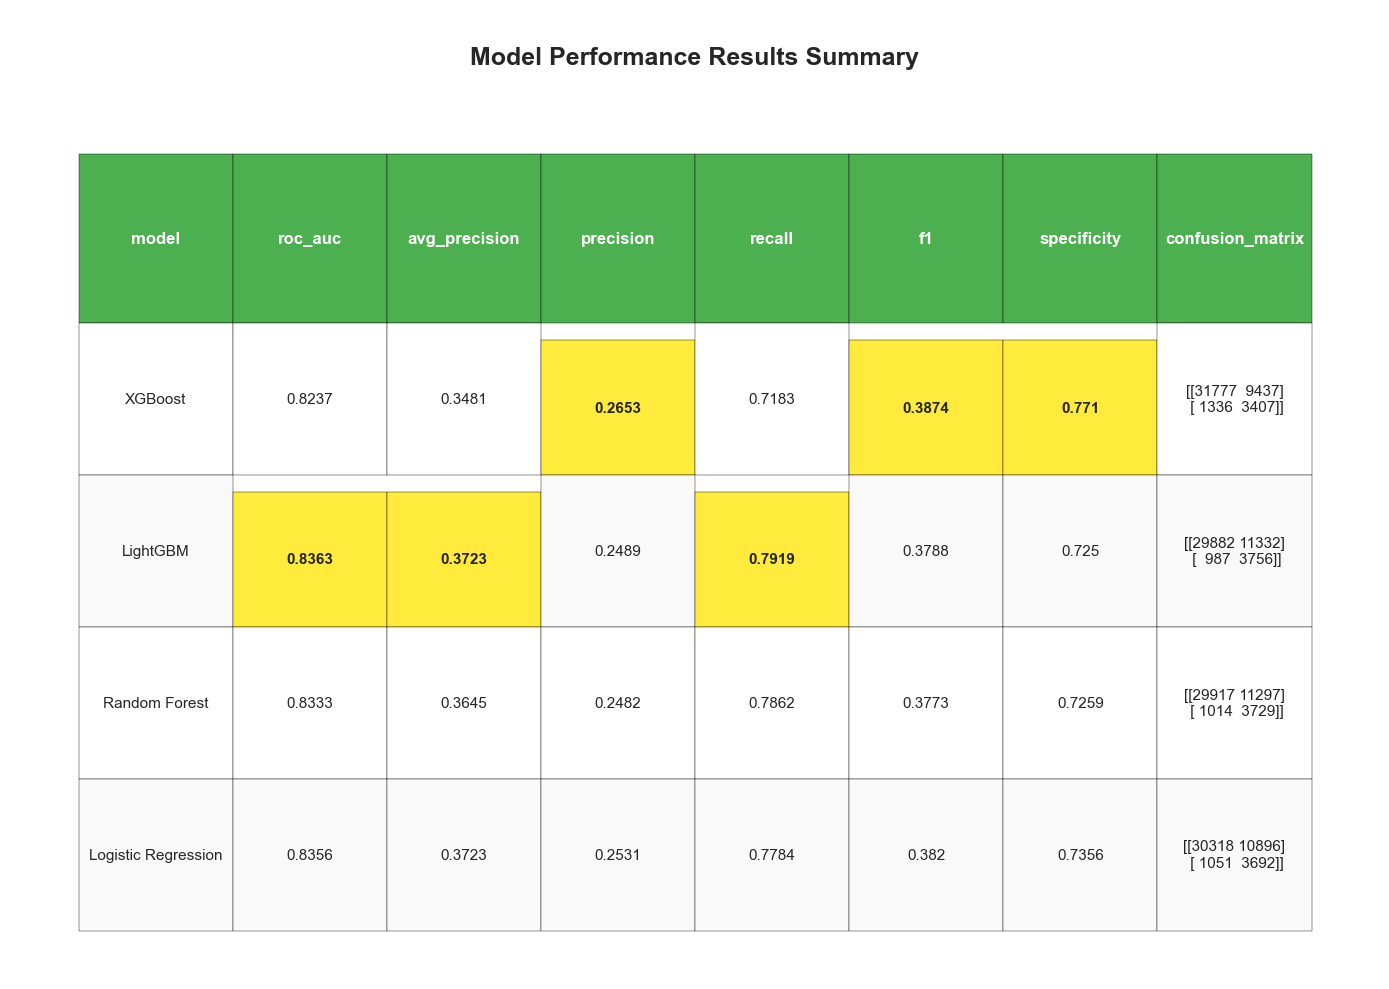

In [362]:
# Separate Results Table Plot with Increased Cell Spacing
def plot_results_table(results):
    """Create a separate plot showing only the results table with increased cell spacing"""
    
    fig, ax = plt.subplots(figsize=(14, 10))  # Increased figure size
    
    try:
        if results:
            # Create results dataframe
            results_df = pd.DataFrame(results).round(4)
            
            # Hide the axis
            ax.axis('off')
            
            # Add title just above the table
            ax.text(0.5, 0.95, 'Model Performance Results Summary', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=18, fontweight='bold')
            
            # Create table with more spacing - positioned lower to make room for title
            table = ax.table(
                cellText=results_df.values,
                colLabels=results_df.columns,
                cellLoc='center',
                loc='center',
                bbox=[0.05, 0.05, 0.9, 0.8]  # Adjusted y-position to 0.05 to make room for title
            )
            
            # Style the table with more spacing
            table.auto_set_font_size(False)
            table.set_fontsize(11)  # Slightly smaller font to accommodate spacing
            table.scale(1.8, 3.0)   # Increased vertical scaling for more row height
            
            # Increase cell padding
            for key, cell in table.get_celld().items():
                cell.set_height(0.15)  # Increase row height
                cell.set_width(0.18)   # Increase column width
            
            # Style header row
            for j in range(len(results_df.columns)):
                table[(0, j)].set_facecolor('#4CAF50')
                table[(0, j)].set_text_props(weight='bold', color='white', size=12)
                table[(0, j)].set_height(0.2)  # Even taller header row
            
            # Style alternate rows for better readability
            for i in range(1, len(results_df) + 1):
                row_height = 0.18  # Increased row height
                table[(i, 0)].set_height(row_height)  # Set height for first cell
                
                if i % 2 == 0:
                    for j in range(len(results_df.columns)):
                        table[(i, j)].set_facecolor('#f9f9f9')
                        table[(i, j)].set_height(row_height)
                else:
                    for j in range(len(results_df.columns)):
                        table[(i, j)].set_height(row_height)
            
            # Highlight best scores in each column (excluding model names)
            numeric_columns = results_df.select_dtypes(include=[np.number]).columns
            for col_idx, col_name in enumerate(results_df.columns):
                if col_name in numeric_columns:
                    values = results_df[col_name].values
                    best_idx = np.argmax(values) if col_name != 'fit_time' else np.argmin(values)
                    table[(best_idx + 1, col_idx)].set_facecolor('#FFEB3B')
                    table[(best_idx + 1, col_idx)].set_text_props(weight='bold')
                    table[(best_idx + 1, col_idx)].set_height(0.16)  # Ensure consistent height
            
        else:
            ax.text(0.5, 0.5, 'No results data available', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=14, style='italic')
            ax.set_title('Model Performance Results', fontweight='bold')
            
    except Exception as e:
        ax.text(0.5, 0.5, f'Error creating results table:\n{str(e)}', 
               ha='center', va='center', transform=ax.transAxes,
               fontsize=12, color='red')
        ax.set_title('Results Table Error', fontweight='bold', color='red')
    
    plt.tight_layout()
    plt.show()

# Usage
print("'Model Performance Results', fontweight='bold'")
plot_results_table(results)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

# Method 1: Cross-validation without early stopping
print("Method 1: XGBoost CV without early stopping")

# Create XGBoost model without early stopping
xgb_model_simple = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    # Remove early_stopping_rounds for cross-validation
    eval_metric='logloss'
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model_simple, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n🎯 XGBoost Cross-Validation Results (No Early Stopping):")
print(f"ROC-AUC Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

In [179]:
# Select best model based on ROC-AUC
best_result = max(results, key=lambda x: x['roc_auc'])
print(f"\n🏆 BEST MODEL: {best_result['model']}")
print(f"Best ROC-AUC: {best_result['roc_auc']:.4f}")

# Feature importance analysis
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance_df.head(10).to_string(index=False))

# Business interpretation
print(f"\n💡 BUSINESS INSIGHTS:")
print(f"- Dataset successfully encoded: {len(categorical_cols)} categorical variables")
print(f"- Using {X.shape[1]} features for prediction")
print(f"- Heart disease prevalence: {y.mean()*100:.1f}%")
print(f"- Best algorithm handles {scale_pos_weight:.1f}:1 imbalance effectively")


🏆 BEST MODEL: LightGBM
Best ROC-AUC: 0.8363

🔍 TOP 10 MOST IMPORTANT FEATURES:
            feature  importance
Any_Chronic_Disease    0.268514
             HighBP    0.101989
            GenHlth    0.081075
             Stroke    0.058167
                Sex    0.054295
          Age_Group    0.050092
                Age    0.045516
           HighChol    0.037437
           DiffWalk    0.036879
             Smoker    0.019788

💡 BUSINESS INSIGHTS:
- Dataset successfully encoded: 5 categorical variables
- Using 28 features for prediction
- Heart disease prevalence: 10.3%
- Best algorithm handles 8.7:1 imbalance effectively


In [318]:
# Select best model based on ROC-AUC
if results:
    best_result = max(results, key=lambda x: x['roc_auc'])
    print(f"\n🏆 BEST MODEL: {best_result['model']}")
    print(f"Best ROC-AUC: {best_result['roc_auc']:.4f}")
    print(f"Best F1-Score: {best_result['f1']:.4f}")

# Feature importance analysis
print(f"\n🔍 XGBOOST FEATURE IMPORTANCE:")
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(10).to_string(index=False))

# Logistic Regression coefficients interpretation
print(f"\n🔍 LOGISTIC REGRESSION COEFFICIENTS:")
lr_coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print(lr_coefficients.head(10).to_string(index=False))

# Business interpretation
print(f"\n💡 BUSINESS INSIGHTS:")
print(f"- Total models compared: 4 (XGBoost, LightGBM, Random Forest, Logistic Regression)")
print(f"- Heart disease prevalence: {y.mean()*100:.1f}%")
print(f"- Imbalance ratio: {scale_pos_weight:.1f}:1")
print(f"- Logistic Regression provides interpretable coefficients")
print(f"- XGBoost typically performs best but Logistic Regression offers better interpretability")

# Key advantages of Logistic Regression for your use case
print(f"\n🎯 WHY LOGISTIC REGRESSION IS VALUABLE:")
print(f"1. Interpretable coefficients - understand feature impact")
print(f"2. Probability calibration - well-calibrated probabilities")
print(f"3. Fast training and prediction")
print(f"4. Handles imbalance well with class weights")
print(f"5. Clinical interpretability - doctors understand odds ratios")


🏆 BEST MODEL: LightGBM
Best ROC-AUC: 0.8363
Best F1-Score: 0.3788

🔍 XGBOOST FEATURE IMPORTANCE:
            feature  importance
Any_Chronic_Disease    0.268514
             HighBP    0.101989
            GenHlth    0.081075
             Stroke    0.058167
                Sex    0.054295
          Age_Group    0.050092
                Age    0.045516
           HighChol    0.037437
           DiffWalk    0.036879
             Smoker    0.019788

🔍 LOGISTIC REGRESSION COEFFICIENTS:
  feature  coefficient  abs_coefficient
  GenHlth     0.492134         0.492134
Age_Group     0.415025         0.415025
      Age     0.415025         0.415025
      Sex     0.403278         0.403278
 HighChol     0.313058         0.313058
   HighBP     0.278176         0.278176
   Stroke     0.229621         0.229621
   Smoker     0.188123         0.188123
 DiffWalk     0.128940         0.128940
CholCheck     0.117533         0.117533

💡 BUSINESS INSIGHTS:
- Total models compared: 4 (XGBoost, LightGBM, Rand

In [183]:
# Odds Ratio Calculation (for clinical interpretation)
print(f"\n📈 LOGISTIC REGRESSION ODDS RATIOS (Top 10):")
odds_ratios = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_model.coef_[0],
    'odds_ratio': np.exp(lr_model.coef_[0])
}).sort_values('odds_ratio', key=abs, ascending=False)

print(odds_ratios.head(10).round(4).to_string(index=False))

# Interpretation examples
print(f"\n💡 ODDS RATIO INTERPRETATION EXAMPLES:")
for _, row in odds_ratios.head(5).iterrows():
    if row['odds_ratio'] > 1:
        print(f"- {row['feature']}: Odds ratio = {row['odds_ratio']:.3f} (INCREASES heart disease risk)")
    else:
        print(f"- {row['feature']}: Odds ratio = {row['odds_ratio']:.3f} (DECREASES heart disease risk)")

# Model performance summary
print(f"\n📊 FINAL MODEL RANKING:")
ranked_models = sorted(results, key=lambda x: x['roc_auc'], reverse=True)
for i, model in enumerate(ranked_models, 1):
    print(f"{i}. {model['model']:>20}: ROC-AUC = {model['roc_auc']:.4f}, F1 = {model['f1']:.4f}")


📈 LOGISTIC REGRESSION ODDS RATIOS (Top 10):
  feature  coefficient  odds_ratio
  GenHlth       0.4921      1.6358
Age_Group       0.4150      1.5144
      Age       0.4150      1.5144
      Sex       0.4033      1.4967
 HighChol       0.3131      1.3676
   HighBP       0.2782      1.3207
   Stroke       0.2296      1.2581
   Smoker       0.1881      1.2070
 DiffWalk       0.1289      1.1376
CholCheck       0.1175      1.1247

💡 ODDS RATIO INTERPRETATION EXAMPLES:
- GenHlth: Odds ratio = 1.636 (INCREASES heart disease risk)
- Age_Group: Odds ratio = 1.514 (INCREASES heart disease risk)
- Age: Odds ratio = 1.514 (INCREASES heart disease risk)
- Sex: Odds ratio = 1.497 (INCREASES heart disease risk)
- HighChol: Odds ratio = 1.368 (INCREASES heart disease risk)

📊 FINAL MODEL RANKING:
1.             LightGBM: ROC-AUC = 0.8363, F1 = 0.3788
2.  Logistic Regression: ROC-AUC = 0.8356, F1 = 0.3820
3.        Random Forest: ROC-AUC = 0.8333, F1 = 0.3773
4.              XGBoost: ROC-AUC = 0.8237,

##  model saving for deployment 

In [185]:
import pickle
features_list = ['Any_Chronic_Disease', 'HighBP', 'GenHlth', 'Stroke', 'Sex', 'Age_Group', 'Age', 'HighChol', 'DiffWalk', 'Smoker']
# Save the model and top 10 features
pickle.dump({'model': lgb_model, 'features':features_list }, open('heart_disease_model.pkl', 'wb'))